# PTB-XL ECG Deep Learning Pipeline
## A Step-by-Step Explanation with Python Code and Flow Diagrams

This notebook explains the full pipeline from raw ECG files on disk to a published, reproducible benchmark — the exact pipeline your CS-598 project proposes as a PyHealth contribution.

```
Raw PTB-XL files on disk
        ↓ PTBXLDataset.process_EEG_data()
Structured patient dictionary (18,885 patients × ECG records)
        ↓ dataset.set_task(ptbxl_superdiagnostic_fn)
SampleDataset (list of windowed samples with multi-hot labels)
        ↓ split_by_patient()
Train / Val / Test splits (no patient leakage)
        ↓ PyHealth Trainer + your model
Trained DNN (ResNet1d, BiLSTM, Transformer...)
        ↓ trainer.evaluate()
ROC-AUC macro + F1 macro scores  ← reproducible benchmark
        ↓
Published as a Colab notebook anyone can run
```

Each section below: (1) explains what is happening conceptually, (2) shows the relevant Python code, and (3) renders a flow diagram for that stage.

---
## Section 1 — Install and Import Dependencies

In [17]:
# ── Standard library & scientific stack ──────────────────────────────────────
import ast
import os
import pickle
import sys
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, f1_score

# ─────────────────────────────────────────────────────────────────────────────
# PyHealth — the medical-AI framework used throughout this notebook.
#
# Install once with:   pip install pyhealth
#
# PyHealth components used:
#   • BaseSignalDataset — abstract base class for signal (ECG/EEG) datasets
#   • SampleSignalDataset — wraps List[Dict] of task samples, handles epoch_path
#   • split_by_patient — patient-level train/val/test split (no leakage)
#   • get_dataloader — converts a SampleSignalDataset subset into a PyTorch DataLoader
#   • SparcNet — DenseNet-based 1D signal classification model
#   • BaseModel — abstract base for building custom PyHealth-compatible models
#   • Trainer — training loop with early stopping + evaluation
#   • multilabel_metrics_fn — computes roc_auc_macro, f1_macro, etc.
# ─────────────────────────────────────────────────────────────────────────────
from pyhealth.datasets import (
    BaseSignalDataset,
    SampleSignalDataset,
    get_dataloader,
    split_by_patient,
)
from pyhealth.models import BaseModel, SparcNet
from pyhealth.trainer import Trainer
from pyhealth.metrics import multilabel_metrics_fn

warnings.filterwarnings("ignore", category=FutureWarning, module="dask")

print("✅  All imports successful")
print(f"   PyTorch : {torch.__version__}")
print(f"   Device  : {'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'}")

try:
    import pyhealth
    print(f"   PyHealth: {pyhealth.__version__}")
except Exception:
    print("   PyHealth: (version not exposed)")

DEVICE = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"


✅  All imports successful
   PyTorch : 2.8.0
   Device  : mps
   PyHealth: 1.1.6


---
## Section 2 — Full Pipeline Flow Diagram

Before diving in, look at the entire pipeline end-to-end.  
Each box below corresponds to one section of this notebook.

/var/folders/80/l6974fzd6jv2bwljchsl6r040000gn/T/ipykernel_1210/3496406396.py:54: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/80/l6974fzd6jv2bwljchsl6r040000gn/T/ipykernel_1210/3496406396.py:54: UserWarning: Glyph 127959 (\N{BUILDING CONSTRUCTION}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/80/l6974fzd6jv2bwljchsl6r040000gn/T/ipykernel_1210/3496406396.py:54: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/80/l6974fzd6jv2bwljchsl6r040000gn/T/ipykernel_1210/3496406396.py:54: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/80/l6974fzd6jv2bwljchsl6r040000gn/T/ipykernel_1210/3496406396.py:54: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/.venv/lib/python3.9/site-packages/IPython/co

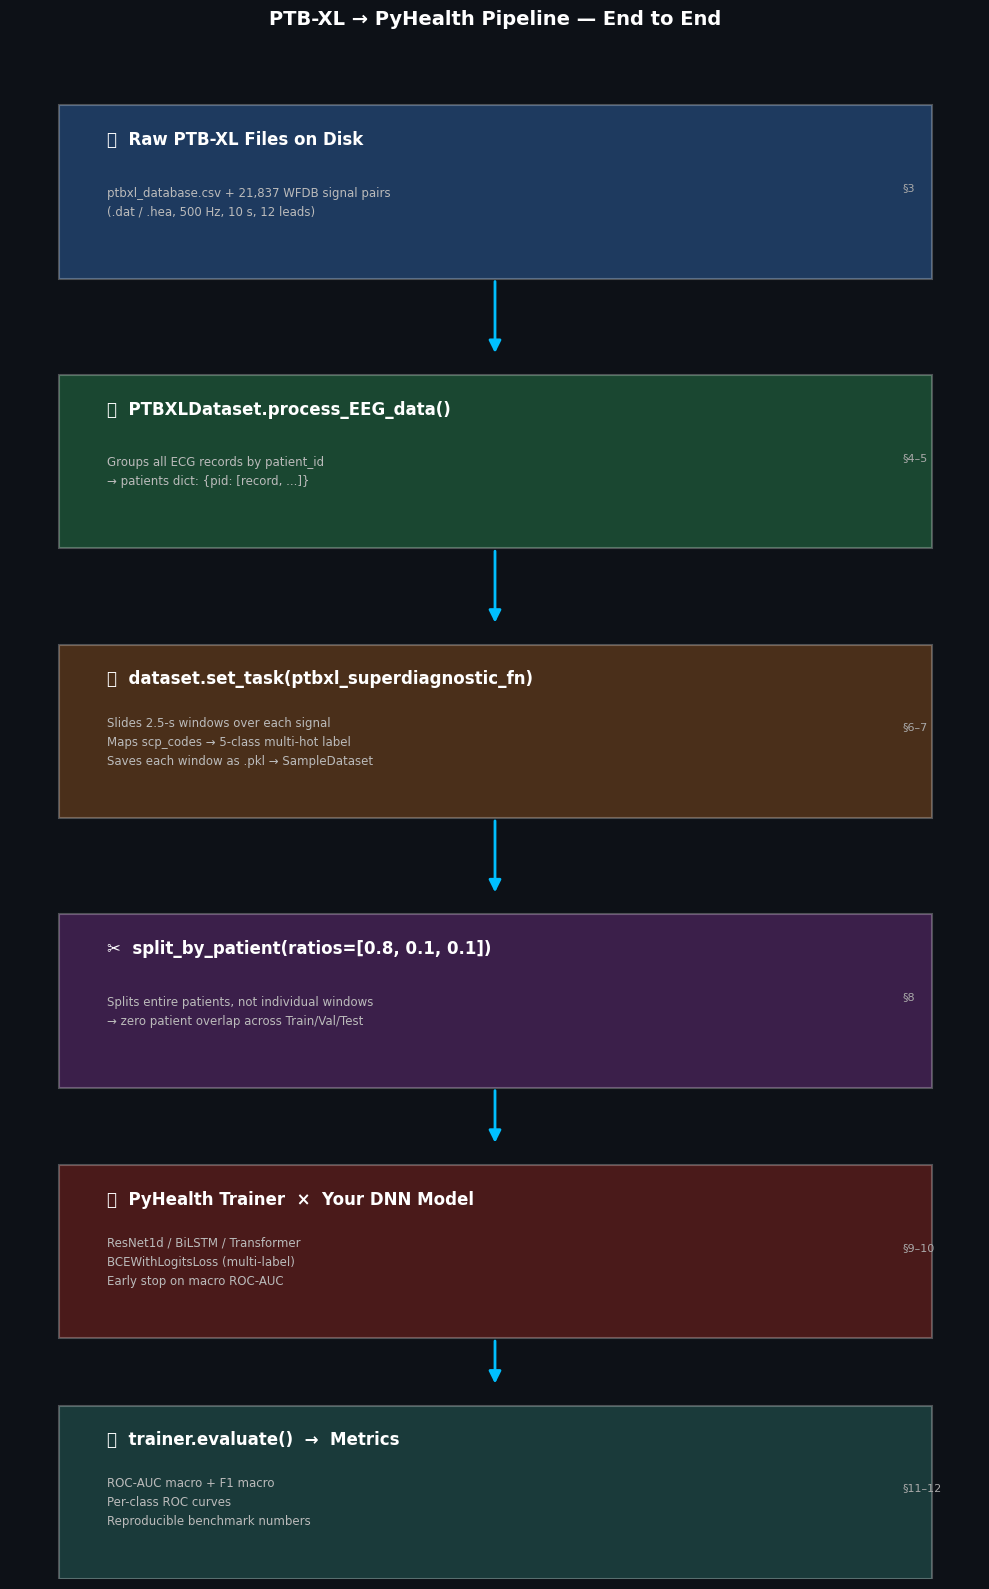

In [3]:
def draw_pipeline_overview():
    """Draw a top-level pipeline overview showing all 8 stages."""
    fig, ax = plt.subplots(figsize=(10, 16))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 16)
    ax.axis("off")
    fig.patch.set_facecolor("#0d1117")

    # ── Stage definitions ─────────────────────────────────────────────────────
    stages = [
        # (y_center, box_color, text_color, icon, title, subtitle, section)
        (14.5, "#1e3a5f", "white",  "💾", "Raw PTB-XL Files on Disk",
         "ptbxl_database.csv + 21,837 WFDB signal pairs\n(.dat / .hea, 500 Hz, 10 s, 12 leads)", "§3"),
        (11.7, "#1a4731", "white",  "🏗️", "PTBXLDataset.process_EEG_data()",
         "Groups all ECG records by patient_id\n→ patients dict: {pid: [record, ...]}", "§4–5"),
        (8.9,  "#4a2f1a", "white",  "🏷️", "dataset.set_task(ptbxl_superdiagnostic_fn)",
         "Slides 2.5-s windows over each signal\nMaps scp_codes → 5-class multi-hot label\nSaves each window as .pkl → SampleDataset", "§6–7"),
        (6.1,  "#3b1f4a", "white",  "✂️", "split_by_patient(ratios=[0.8, 0.1, 0.1])",
         "Splits entire patients, not individual windows\n→ zero patient overlap across Train/Val/Test", "§8"),
        (3.5,  "#4a1a1a", "white",  "🧠", "PyHealth Trainer  ×  Your DNN Model",
         "ResNet1d / BiLSTM / Transformer\nBCEWithLogitsLoss (multi-label)\nEarly stop on macro ROC-AUC", "§9–10"),
        (1.0,  "#1a3a3a", "#00ffcc","📊", "trainer.evaluate()  →  Metrics",
         "ROC-AUC macro + F1 macro\nPer-class ROC curves\nReproducible benchmark numbers", "§11–12"),
    ]

    for (y, bg, fg, icon, title, subtitle, section) in stages:
        # box
        rect = plt.Rectangle((0.5, y - 1.0), 9.0, 1.8,
                              facecolor=bg, edgecolor="#ffffff44",
                              linewidth=1.5, zorder=2)
        ax.add_patch(rect)
        # section badge
        ax.text(9.2, y - 0.05, section, color="#aaaaaa", fontsize=8,
                ha="left", va="center", zorder=3)
        # icon + title
        ax.text(1.0, y + 0.45, icon + "  " + title,
                color="white", fontsize=12, fontweight="bold",
                va="center", ha="left", zorder=3)
        # subtitle
        ax.text(1.0, y - 0.2, subtitle,
                color="#bbbbbb", fontsize=8.5, va="center", ha="left",
                linespacing=1.6, zorder=3)

    # ── Arrows between boxes ──────────────────────────────────────────────────
    arrow_y_pairs = [(13.5, 12.7), (10.7, 9.9), (7.9, 7.1), (5.1, 4.5), (2.5, 2.0)]
    for (y1, y2) in arrow_y_pairs:
        ax.annotate("", xy=(5.0, y2), xytext=(5.0, y1),
                    arrowprops=dict(arrowstyle="-|>", color="#00bfff",
                                    lw=2.0, mutation_scale=18),
                    zorder=4)

    ax.set_title("PTB-XL → PyHealth Pipeline — End to End",
                 color="white", fontsize=14, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.show()

draw_pipeline_overview()

---
## Section 3 — Raw PTB-XL Files on Disk

### What is PTB-XL?
PTB-XL (Wagner et al., 2020, PhysioNet) is the **largest publicly available clinical 12-lead ECG dataset**:
- **21,837 recordings** from **18,885 unique patients**
- Each recording: 10 seconds × 12 leads × 500 Hz = **60,000 samples per recording**
- Labels: physician-annotated SCP codes (e.g. `NORM`, `MI`, `AFIB`) with confidence scores

### Directory structure on disk

```
ptb-xl-1.0.1/
├── ptbxl_database.csv        ← metadata for all 21,837 recordings
├── scp_statements.csv        ← lookup: each SCP code → diagnostic class
├── records100/               ← 100 Hz versions of signals (WFDB format)
│   ├── 00000/
│   │   ├── 00001_lr.dat      ← raw binary signal data
│   │   └── 00001_lr.hea      ← header: leads, sample rate, calibration
│   └── ...
└── records500/               ← 500 Hz versions (used by the paper)
    ├── 00000/
    │   ├── 00001_hr.dat
    │   └── 00001_hr.hea
    └── ...
```

### Key columns in `ptbxl_database.csv`

| Column | Meaning |
|---|---|
| `ecg_id` | Unique recording ID (1–21837) |
| `patient_id` | Which patient (1–18885) — multiple ECGs per patient |
| `filename_hr` | Path to 500 Hz WFDB file relative to root |
| `filename_lr` | Path to 100 Hz WFDB file |
| `scp_codes` | Dict of `{SCP_code: confidence}` e.g. `{"NORM": 100.0}` |
| `strat_fold` | Cross-validation fold assignment (1–10) |
| `age`, `sex` | Patient demographics |

Data format : ptbxl_wfdb
DB CSV      : /Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/ptbxl_database.csv  ✅
WFDB root   : /Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/WFDB  ✅
ptbxl_database.csv shape : (21799, 27)
Unique patients          : 18,869
ECG recordings           : 21,799

First 3 rows (key columns):


,patient_id,age,sex,scp_codes,strat_fold
ecg_id,,,,,
1,15709.0,56.0,1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",3
2,13243.0,19.0,0,"{'NORM': 80.0, 'SBRAD': 0.0}",2
3,20372.0,37.0,1,"{'NORM': 100.0, 'SR': 0.0}",5



Signal file : HR00001.mat
Raw shape   : (12, 5000)  → (leads=12, samples=5000 @ 500 Hz)
Range (mV)  : [-7.220, 3.450]
SCP codes   : {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}


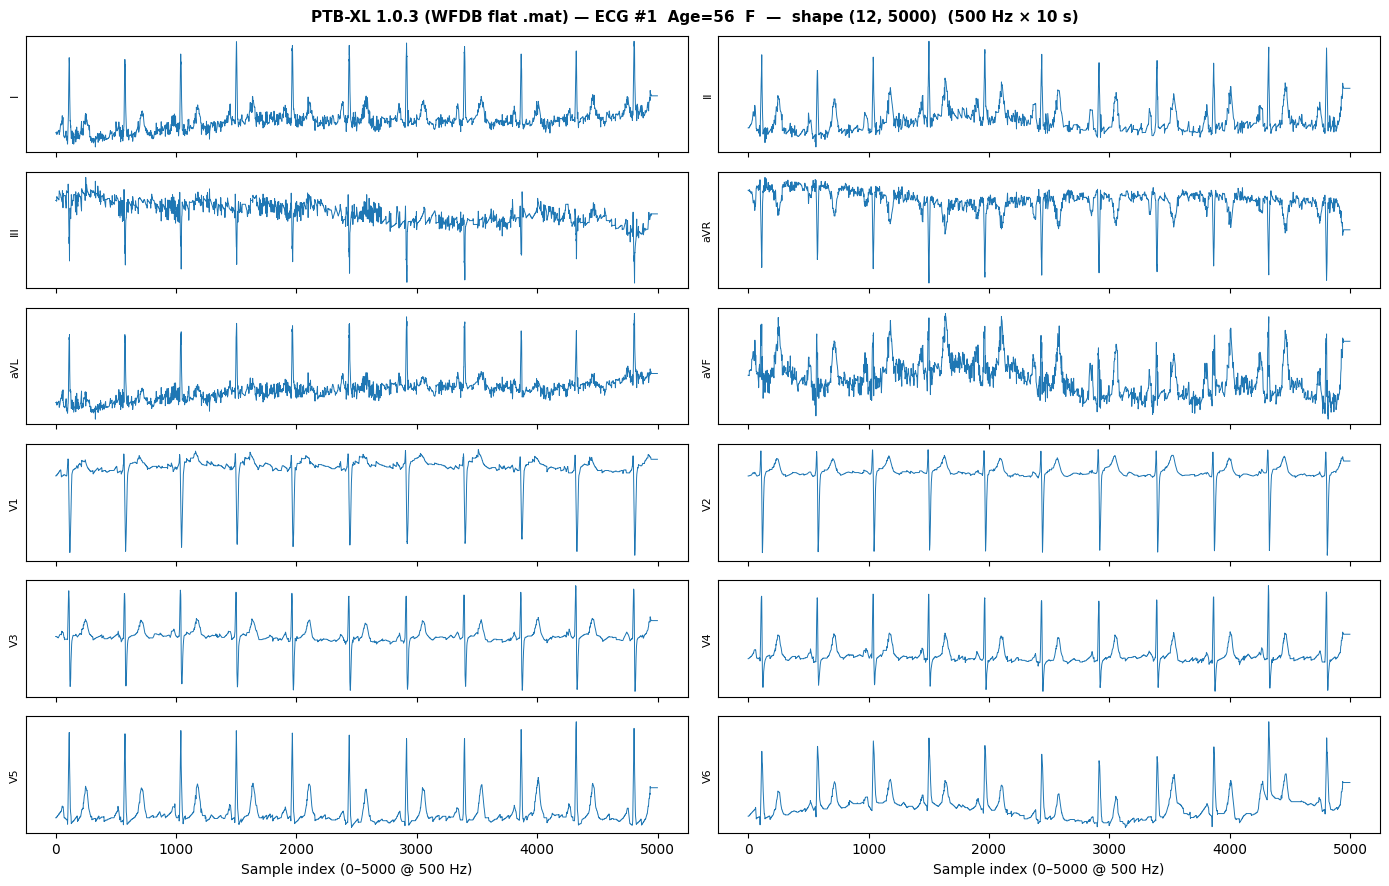


✅  Shape: (12, 5000)  (12 leads × 5000 samples @ 500 Hz = 10s)


In [4]:
import ast
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Data roots ────────────────────────────────────────────────────────────────
_PROJECT_ROOT = Path("/Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/PyHealth/cs598_project")
_DB_CSV       = _PROJECT_ROOT / "ptbxl_database.csv"
_WFDB_ROOT    = _PROJECT_ROOT / "WFDB"

_PTBXL_CINC = (
    _PROJECT_ROOT.parent.parent /
    "classification-of-12-lead-ecgs-the-physionetcomputing-in-cardiology-challenge-2020-1.0.2"
    / "training" / "ptb-xl"
)

# ── Auto-detect best available format ─────────────────────────────────────────
if _DB_CSV.exists() and _WFDB_ROOT.is_dir():
    DATA_FORMAT = "ptbxl_wfdb"          # ptbxl_database.csv + WFDB/ flat .mat files
elif (_PTBXL_CINC / "ptbxl-pyhealth.csv").exists():
    DATA_FORMAT = "cinc2020"
else:
    DATA_FORMAT = "synthetic"

print(f"Data format : {DATA_FORMAT}")
print(f"DB CSV      : {_DB_CSV}  {'✅' if _DB_CSV.exists() else '❌'}")
print(f"WFDB root   : {_WFDB_ROOT}  {'✅' if _WFDB_ROOT.is_dir() else '❌'}")

LEAD_NAMES = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

# ─────────────────────────────────────────────────────────────────────────────
def demo_raw_files(fmt):
    if fmt == "ptbxl_wfdb":
        _demo_ptbxl_wfdb(_DB_CSV, _WFDB_ROOT)
    elif fmt == "cinc2020":
        _demo_cinc2020(_PTBXL_CINC)
    else:
        print("No real data found. Generating SYNTHETIC demo...\n")
        _show_synthetic_structure()


def _demo_ptbxl_wfdb(db_csv: Path, wfdb_root: Path):
    """
    Show metadata from ptbxl_database.csv and load a real signal
    from the WFDB/ flat .mat folder (500 Hz, channel-first).
    """
    df = pd.read_csv(db_csv, index_col="ecg_id")
    df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

    print(f"ptbxl_database.csv shape : {df.shape}")
    print(f"Unique patients          : {df['patient_id'].nunique():,}")
    print(f"ECG recordings           : {len(df):,}\n")
    print("First 3 rows (key columns):")
    display(df[["patient_id","age","sex","scp_codes","strat_fold"]].head(3))

    # Load signal: ecg_id → WFDB/HR{ecg_id:05d}.mat
    ecg_id = df.index[0]   # = 1
    mat_path = wfdb_root / f"HR{ecg_id:05d}.mat"
    data = scipy.io.loadmat(str(mat_path))
    signal = data["val"].astype(float)   # shape: (12, 5000) channel-first, 500 Hz
    # Convert ADC → mV: gain = 200 ADC units/mV (from .hea file)
    signal_mv = signal / 200.0

    print(f"\nSignal file : {mat_path.name}")
    print(f"Raw shape   : {signal.shape}  → (leads=12, samples=5000 @ 500 Hz)")
    print(f"Range (mV)  : [{signal_mv.min():.3f}, {signal_mv.max():.3f}]")
    print(f"SCP codes   : {df.loc[ecg_id, 'scp_codes']}")
    _plot_raw_signal(signal_mv, fs=500,
                     title=f"PTB-XL 1.0.3 (WFDB flat .mat) — ECG #{ecg_id}  "
                           f"Age={int(df.loc[ecg_id,'age'])}  "
                           f"{'F' if df.loc[ecg_id,'sex']==1 else 'M'}")


def _demo_cinc2020(root: Path):
    """Show metadata and a real signal from CinC 2020 PTB-XL challenge data."""
    df = pd.read_csv(root / "ptbxl-pyhealth.csv")
    print(f"ptbxl-pyhealth.csv shape : {df.shape}")
    print(f"ECG recordings           : {len(df):,}\n")
    display(df[["patient_id","record_id","age","sex","scp_codes","group"]].head(3))

    row = df.iloc[0]
    mat = scipy.io.loadmat(str(root / row["signal_file"]))
    signal = mat["val"].astype(float) / 200.0   # ADC → mV
    fs = int(row["sampling_rate"])
    print(f"\nSignal loaded (CinC .mat) : {signal.shape}")
    _plot_raw_signal(signal, fs, title="CinC 2020 PTB-XL — Real 12-lead ECG (500 Hz)")


def _show_synthetic_structure():
    t = np.linspace(0, 10, 5000)
    ecg_sim = np.zeros((12, 5000))
    for lead in range(12):
        ecg_sim[lead] = (0.03 * np.sin(2*np.pi*1.2*t)
                       + 1.2  * np.exp(-((t % (1/1.2) - 0.15)**2) / 0.0002)
                       - 0.1  * np.sin(2*np.pi*1.2*t + 0.5)
                       + 0.01 * np.random.randn(5000))
    _plot_raw_signal(ecg_sim, 500, title="SYNTHETIC 12-lead ECG (demo)")


def _plot_raw_signal(signal, fs, title="12-lead ECG"):
    """signal shape: (12, n_samples)."""
    n = signal.shape[1]
    fig, axes = plt.subplots(6, 2, figsize=(14, 9), sharex=True)
    fig.suptitle(f"{title}  —  shape {signal.shape}  ({fs} Hz × {n//fs} s)",
                 fontsize=11, fontweight="bold")
    axes_flat = axes.flatten()
    for i in range(12):
        axes_flat[i].plot(signal[i], linewidth=0.7, color="#1f77b4")
        axes_flat[i].set_ylabel(LEAD_NAMES[i], fontsize=8)
        axes_flat[i].set_yticks([])
    axes_flat[-1].set_xlabel(f"Sample index (0–{n} @ {fs} Hz)")
    axes_flat[-2].set_xlabel(f"Sample index (0–{n} @ {fs} Hz)")
    plt.tight_layout()
    plt.show()
    print(f"\n✅  Shape: {signal.shape}  (12 leads × {n} samples @ {fs} Hz = {n//fs}s)")


demo_raw_files(DATA_FORMAT)


---
## Section 4 — `PTBXLDataset.process_EEG_data()` — Pipeline Stage 1

`process_EEG_data()` is the **only abstract method** you must implement when subclassing `BaseSignalDataset`.  
Its job is to convert the raw files into a single structured dictionary.

### What happens inside it — sub-flow

```
ptbxl_database.csv
        │
        ▼
Read CSV → parse scp_codes column (string → dict)
        │
        ▼
For each row: build a record dict with wfdb_path, scp_codes, strat_fold, age, sex
        │
        ▼
Group records by patient_id (groupby)
        │
        ▼
Return patients = {
    "1":    [ {ecg_id:"1", wfdb_path:"...", scp_codes:{...}, strat_fold:9}, ... ],
    "2":    [ {ecg_id:"2", wfdb_path:"...", ...} ],
    ...
    "18885":[ ... ]
}
```

**Key design principle:** `process_EEG_data()` does **NOT** load signal arrays — it only stores file paths.  
Signal loading happens lazily, inside the task function (Section 6), so memory stays low.

In [5]:
# ── STEP 4: PTBXLDataset — extends PyHealth's BaseSignalDataset ──────────────
#
# PyHealth's BaseSignalDataset is the standard abstract base class for any
# dataset that stores one signal (ECG, EEG, waveform) per patient.
#
# Subclass contract:
#   • Override process_EEG_data() → return { patient_id: [record_dict, ...] }
#   • Calling dataset.set_task(task_fn) iterates this dict, calls task_fn on
#     each patient's records list, and returns a SampleSignalDataset.
#
# Key design: No signals are loaded here — only file paths are stored
# (lazy loading happens inside the task function).

from scipy.io import loadmat as scipy_loadmat


class PTBXLDataset(BaseSignalDataset):
    """
    PTB-XL 12-lead ECG dataset.

    Extends ``pyhealth.datasets.BaseSignalDataset`` so it is fully
    compatible with PyHealth's Trainer, splitter, and model APIs.

    Directory layout expected::

        root/
          ptbxl_database.csv
          scp_statements.csv
          WFDB/
            HR00001.mat   (12-lead ECG, 12×5000, 500 Hz)
            HR00001.hea
            HR00002.mat
            ...

    Each ``WFDB/HR{:05d}.mat`` file stores the signal in
    ``mat["val"]`` (int16, ADC counts; divide by 200 to get mV).
    """

    def __init__(self, root: str, sampling_rate: int = 500, **kwargs):
        self._ptbxl_root     = Path(root)
        self._sampling_rate  = sampling_rate
        # super().__init__ immediately calls process_EEG_data()
        super().__init__(root=root, dataset_name="ptbxl", **kwargs)

    def process_EEG_data(self) -> dict:
        """
        Read ``ptbxl_database.csv`` and group ECG records by patient.

        Each patient entry stores:
            patient_id  – str
            ecg_id      – str (integer ecg_id from CSV)
            mat_path    – str (absolute path to WFDB/HR{id:05d}.mat)
            scp_codes   – dict  {code: confidence_float}
            strat_fold  – int (1–10)
            age / sex   – float / int (demographics, optional)
        """
        root     = self._ptbxl_root
        csv_path = root / "ptbxl_database.csv"

        if not csv_path.exists():
            print("[PTBXLDataset] ptbxl_database.csv not found — using synthetic data.")
            return _build_synthetic_patients()

        df = pd.read_csv(csv_path, index_col="ecg_id")
        df["scp_codes"]  = df["scp_codes"].apply(ast.literal_eval)
        df["patient_id"] = df["patient_id"].astype(int).astype(str)

        patients = defaultdict(list)
        wfdb_dir = root / "WFDB"

        for ecg_id, row in df.iterrows():
            # Flat WFDB layout:  WFDB/HR{ecg_id:05d}.mat
            mat_path = wfdb_dir / f"HR{int(ecg_id):05d}.mat"
            patients[row["patient_id"]].append({
                "patient_id": row["patient_id"],
                "ecg_id":     str(ecg_id),
                "mat_path":   str(mat_path),  # ← scipy.io.loadmat path
                "scp_codes":  row["scp_codes"],
                "strat_fold": int(row["strat_fold"]),
                "age":        row.get("age"),
                "sex":        row.get("sex"),
            })
        return dict(patients)

    def stat(self):
        total = sum(len(v) for v in self.patients.values())
        folds = defaultdict(int)
        for recs in self.patients.values():
            for r in recs:
                folds[r["strat_fold"]] += 1
        print(f"{'─'*54}")
        print(f"  PyHealth PTBXLDataset  (BaseSignalDataset subclass)")
        print(f"  Patients    : {len(self.patients):,}")
        print(f"  ECG records : {total:,}")
        print(f"  Avg ECGs/pt : {total/len(self.patients):.2f}")
        print(f"  Strat folds : {dict(sorted(folds.items()))}")
        print(f"{'─'*54}")


def _build_synthetic_patients(n_patients: int = 200,
                               ecgs_per_max: int = 3) -> dict:
    """Minimal synthetic patients dict — same schema as real PTB-XL."""
    rng  = np.random.default_rng(42)
    DIAG = ["NORM", "CD", "HYP", "MI", "STTC"]
    out  = {}
    ecg_id = 1
    for pid in range(1, n_patients + 1):
        n = rng.integers(1, ecgs_per_max + 1)
        recs = []
        for _ in range(n):
            chosen = rng.choice(DIAG, size=rng.integers(1, 3), replace=False)
            scp = {c: float(rng.integers(60, 101)) for c in chosen}
            recs.append({
                "patient_id": str(pid),
                "ecg_id":     str(ecg_id),
                "mat_path":   "",            # no real file → synthetic signal
                "scp_codes":  scp,
                "strat_fold": int((pid % 10) + 1),
                "age":        float(rng.integers(18, 85)),
                "sex":        int(rng.integers(0, 2)),
            })
            ecg_id += 1
        out[str(pid)] = recs
    return out


# ── Instantiate ───────────────────────────────────────────────────────────────
PTBXL_ROOT = Path("/Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/PyHealth/cs598_project")

print("Initialising PyHealth PTBXLDataset …")
dataset = PTBXLDataset(root=str(PTBXL_ROOT), sampling_rate=500)
dataset.stat()


Initialising PyHealth PTBXLDataset …
──────────────────────────────────────────────────────
  PyHealth PTBXLDataset  (BaseSignalDataset subclass)
  Patients    : 18,869
  ECG records : 21,799
  Avg ECGs/pt : 1.16
  Strat folds : {1: 2175, 2: 2181, 3: 2192, 4: 2174, 5: 2174, 6: 2173, 7: 2176, 8: 2173, 9: 2183, 10: 2198}
──────────────────────────────────────────────────────


---
## Section 5 — Inspect the Structured Patient Dictionary

After `process_EEG_data()`, we have `dataset.patients` — a plain Python `dict`.

```
dataset.patients = {
    "1"     : [ {ecg_id:"1",  wfdb_path:"...", scp_codes:{"NORM":100.0}, strat_fold:9 , age:52, sex:0},
                {ecg_id:"12", wfdb_path:"...", scp_codes:{"NORM":90.0},  strat_fold:9 , age:52, sex:0} ],
    "2"     : [ {ecg_id:"3",  wfdb_path:"...", scp_codes:{"MI":80.0,"ISCAL":20.0}, strat_fold:7, ...} ],
    ...
    "18885" : [ ... ]
}
```

**Why group by patient?**  
Because when we later split into Train/Val/Test, we split **at the patient level** —  
all ECGs from one patient stay together in the same split, preventing data leakage.

Type of dataset.patients : <class 'dict'>
Number of patients       : 18,869

Patient ID : 15709
Number of ECG records for this patient : 1

Record #1 keys and values:
  patient_id    : 15709
  ecg_id        : 1
  mat_path      : /Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/WFDB/HR00001.mat
  scp_codes     : {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
  strat_fold    : 3
  age           : 56.0
  sex           : 1


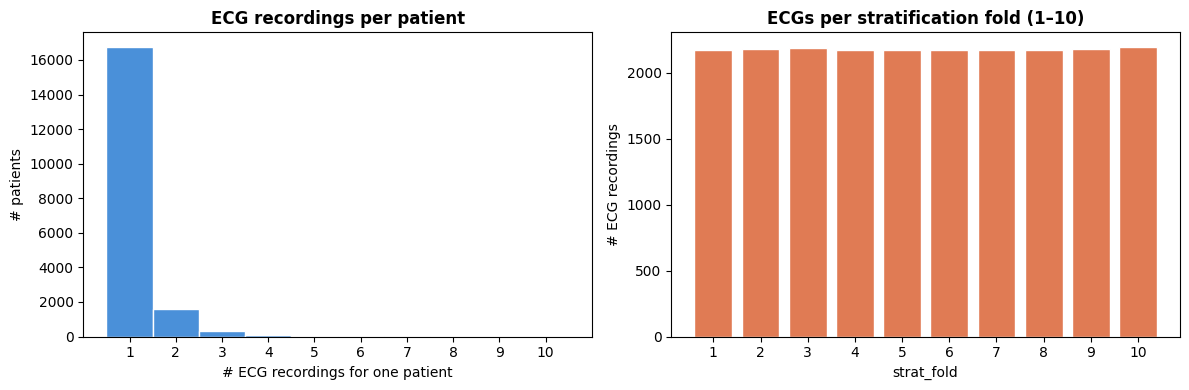


✅  dataset.patients is built. No signals loaded yet — only metadata + file paths.


In [6]:
# ── STEP 5: Inspect the patients dictionary ──────────────────────────────────

print(f"Type of dataset.patients : {type(dataset.patients)}")
print(f"Number of patients       : {len(dataset.patients):,}\n")

# Look at the first patient
first_pid   = list(dataset.patients.keys())[0]
first_recs  = dataset.patients[first_pid]

print(f"Patient ID : {first_pid}")
print(f"Number of ECG records for this patient : {len(first_recs)}\n")
print("Record #1 keys and values:")
for k, v in first_recs[0].items():
    print(f"  {k:<14}: {v}")

# ── Distribution of ECGs per patient ─────────────────────────────────────────
ecg_counts = [len(v) for v in dataset.patients.values()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of ECGs per patient
axes[0].hist(ecg_counts, bins=range(1, max(ecg_counts) + 2),
             color="#4a90d9", edgecolor="white", align="left")
axes[0].set_title("ECG recordings per patient", fontsize=12, fontweight="bold")
axes[0].set_xlabel("# ECG recordings for one patient")
axes[0].set_ylabel("# patients")
axes[0].set_xticks(range(1, max(ecg_counts) + 1))

# Right: strat_fold distribution
all_folds = [r["strat_fold"] for recs in dataset.patients.values() for r in recs]
fold_counts = pd.Series(all_folds).value_counts().sort_index()
axes[1].bar(fold_counts.index, fold_counts.values, color="#e07b54", edgecolor="white")
axes[1].set_title("ECGs per stratification fold (1–10)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("strat_fold")
axes[1].set_ylabel("# ECG recordings")
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()
print("\n✅  dataset.patients is built. No signals loaded yet — only metadata + file paths.")

---
## Section 6 — Apply the Superdiagnostic Task (`dataset.set_task(...)`)

### What is a Task function?

A **task function** is a plain Python function that:

1. Receives **one patient's records** (the list from `dataset.patients[pid]`)
2. Loads the actual signal array from disk for each record
3. Applies a **sliding window** to break the 10-second recording into sub-windows
4. Converts `scp_codes` dict into a **multi-hot label vector**
5. Saves each window as a `.pkl` file (avoids re-loading on every epoch)
6. Returns a `List[Dict]` — one dict per window = one training sample

### The 5 superdiagnostic classes

PTB-XL's SCP codes are organized in a hierarchy. The **superdiagnostic** level has exactly 5 classes:

| Index | Class | Meaning |
|---|---|---|
| 0 | `NORM` | Normal ECG |
| 1 | `CD` | Conduction Disturbance |
| 2 | `HYP` | Hypertrophy |
| 3 | `MI` | Myocardial Infarction |
| 4 | `STTC` | ST/T-change (ischemia signs) |

A recording can have **multiple active classes simultaneously** — this is multi-label classification.  
The label vector `[1, 0, 0, 1, 0]` means "NORM and MI are both present."

### Flow inside `set_task()`:

```
dataset.patients
    │
    ╔═══════════════════════════════════════╗
    ║  for each patient (18,885 patients):  ║
    ║    for each ECG record of that patient║
    ║      1. wfdb.rdsamp(wfdb_path)        ║
    ║         → signal (5000, 12)           ║
    ║      2. scp_codes → 5-class label     ║
    ║      3. Slide window (stride = 625)   ║
    ║         window 0: samples [0:1250]    ║
    ║         window 1: samples [625:1875]  ║
    ║         window 2: samples [1250:2500] ║
    ║         window 3: samples [1875:3125] ║
    ║         window 4: samples [2500:3750] ║
    ║         window 5: samples [3125:4375] ║
    ║         window 6: samples [3750:5000] ║
    ║      4. pickle.dump each window       ║
    ║      5. append sample dict to list    ║
    ╚═══════════════════════════════════════╝
    │
    ▼
SampleDataset.samples = [
    {patient_id:"1", ecg_id:"1", epoch_path:"~/.cache/.../1-1-0.pkl", label:[1,0,0,0,0]},
    {patient_id:"1", ecg_id:"1", epoch_path:"~/.cache/.../1-1-1.pkl", label:[1,0,0,0,0]},
    ...  ← ~7 windows per ECG × 21,837 ECGs ≈ 152,859 total samples
]
```

In [9]:
# ── STEP 6: PyHealth Task Function — ptbxl_superdiagnostic_fn ────────────────
#
# A PyHealth task function:
#   • Takes one patient's record list (from dataset.patients[pid])
#   • Loads the ECG signal (or synthesises one)
#   • Slices into 2.5-second windows with 50% overlap
#   • Maps SCP codes → NORM / CD / HYP / MI / STTC labels
#   • Stores each window as a .pkl file (epoch_path convention from PyHealth)
#   • Returns a List[Dict], one dict per window
#
# Label format required by PyHealth SparcNet in "multilabel" mode:
#   label = List[str], e.g. ["NORM"] or ["CD", "STTC"]
#   (SparcNet.prepare_labels tokenises these → multi-hot tensor)
#
# Pickle format required by PyHealth SampleSignalDataset:
#   {"signal": np.float32(12, T)}   ← ONLY the signal array
#   The "label" key stays in the outer sample dict (not in the pickle)
#   so that SampleSignalDataset.__getitem__ leaves it untouched.
#
# Required keys in each sample dict (SampleSignalDataset contract):
#   patient_id  – str
#   record_id   – str  ← required by SampleSignalDataset._index_record()
#   epoch_path  – str  ← path to pkl with {"signal": ndarray}
#   label       – List[str]

from scipy.io import loadmat as scipy_loadmat

# ── SNOMED / SCP code → superdiagnostic class mapping ────────────────────────
# Source: Table 2 of Strodthoff et al. (2020) and PTB-XL scp_statements.csv
SNOMED_TO_SUPERDIAG = {
    # --------------- NORM -----------------------------------------------
    "NORM":      "NORM",
    # --------------- CD — Conduction Disturbance / Rhythm ---------------
    "LAFB": "CD", "LPFB":  "CD", "IRBBB": "CD", "RBBB": "CD",
    "LBBB": "CD", "IVCD":  "CD", "IAVB":  "CD", "I-AVB": "CD",
    "WPW":  "CD", "SVTAC": "CD", "PSVT":  "CD", "AF":    "CD",
    "AFIB": "CD", "AVNRT": "CD", "AVRT":  "CD",
    # --------------- HYP — Hypertrophy ----------------------------------
    "LVH":     "HYP", "RVH":    "HYP",
    "LAO/LAE": "HYP", "RAO/RAE":"HYP",
    # --------------- MI — Myocardial Infarction -------------------------
    "AMI":   "MI", "IMI":    "MI", "LMI":   "MI", "PMI": "MI",
    "ISCAL": "MI", "ISCIN":  "MI", "ISCAN": "MI",
    "ISCLA": "MI", "ISC_":   "MI",
    # --------------- STTC — ST/T-wave Change ----------------------------
    "STD_":  "STTC", "STE_": "STTC", "NST_": "STTC",
    "STTC":  "STTC", "ANEUR":"STTC",
}

SUPERDIAG_CLASSES = ["NORM", "CD", "HYP", "MI", "STTC"]  # canonical order


def ptbxl_superdiagnostic_fn(record_list: list,
                               epoch_sec: float = 2.5,
                               freq: int         = 500,
                               scp_threshold: float = 50.0) -> list:
    """
    PyHealth task function: converts one patient's ECG records into
    a list of windowed samples for multi-label superdiagnostic classification.

    Args:
        record_list   : list of record dicts from PTBXLDataset.patients[pid]
        epoch_sec     : window length in seconds (2.5 s → 1250 samples @ 500 Hz)
        freq          : sampling rate (500 Hz)
        scp_threshold : minimum SCP confidence (%) to count as positive

    Returns:
        samples : List[Dict], each with keys:
            patient_id  – str
            record_id   – str  (same as ecg_id; required by SampleSignalDataset)
            ecg_id      – str
            epoch_path  – str  (path to pickle containing {"signal": ndarray})
            label       – List[str]  e.g. ["NORM"], ["CD", "STTC"]
    """
    samples    = []
    win_len    = int(freq * epoch_sec)       # 500 × 2.5 = 1250
    stride     = win_len // 2               # 50% overlap
    cache_dir  = Path.home() / ".cache" / "pyhealth_ptbxl" / "windows"
    cache_dir.mkdir(parents=True, exist_ok=True)

    for visit in record_list:
        pid       = visit["patient_id"]
        ecg_id    = visit["ecg_id"]
        mat_path  = visit["mat_path"]
        scp_codes = visit["scp_codes"]

        # ── 1. Build the label as a List[str] (required by SparcNet multilabel) ──
        labels = list({
            SNOMED_TO_SUPERDIAG[c]
            for c, conf in scp_codes.items()
            if c.upper() in SNOMED_TO_SUPERDIAG and float(conf) >= scp_threshold
        })
        if not labels:
            continue  # skip records with no mappable superdiagnostic code

        # ── 2. Load the ECG signal ──────────────────────────────────────────
        if mat_path and Path(mat_path).exists():
            mat    = scipy_loadmat(mat_path)
            signal = mat["val"].astype(np.float32) / 200.0  # ADC → mV  (12, 5000)
        else:
            # Synthetic: 1-lead QRS spike pattern, replicated 12 times
            t      = np.linspace(0, freq * 10 / freq, freq * 10)
            lead   = 0.5 * np.sin(2 * np.pi * 1.2 * t) + np.random.randn(freq * 10) * 0.04
            signal = np.tile(lead, (12, 1)).astype(np.float32)  # (12, 5000)

        # ── 3. Sliding-window segmentation ─────────────────────────────────
        n_windows = max(1, (signal.shape[1] - win_len) // stride + 1)
        for idx in range(n_windows):
            s      = idx * stride
            window = signal[:, s : s + win_len]               # (12, 1250)
            if window.shape[1] < win_len:
                break  # skip the last partial window

            # Save ONLY the signal in the pickle (label stays in outer dict)
            pkl_path = str(cache_dir / f"{pid}_{ecg_id}_{idx}.pkl")
            with open(pkl_path, "wb") as f:
                pickle.dump({"signal": window}, f)

            samples.append({
                "patient_id": pid,
                "record_id":  ecg_id,   # ← required by SampleSignalDataset._index_record()
                "ecg_id":     ecg_id,
                "epoch_path": pkl_path,
                "label":      labels,   # List[str] — kept in outer dict
            })
    return samples


# ── Apply task via PyHealth's BaseSignalDataset.set_task() ────────────────────
print("Calling dataset.set_task(ptbxl_superdiagnostic_fn) …")
print("(uses pandarallel for parallel patient processing)\n")
sample_dataset = dataset.set_task(ptbxl_superdiagnostic_fn)

# ── Patch input_info["label"] for multilabel (label = List[str], dim=2) ──────
# PyHealth 1.1.6 hardcodes dim=0 for "label" in SampleSignalDataset._validate().
# We override it so that get_all_tokens("label") correctly iterates the list.
sample_dataset.input_info["label"] = {"type": str, "dim": 2}

n         = len(sample_dataset)
pos_rates = np.zeros(5)
for s in sample_dataset.samples:
    for cls in s["label"]:
        pos_rates[SUPERDIAG_CLASSES.index(cls)] += 1
pos_rates /= n

print(f"\nPyHealth SampleSignalDataset built: {n:,} samples")
print(f"  input_info: {sample_dataset.input_info}")
print(f"\n  Label prevalence (multi-hot, threshold={50}%):")
for cls, rate in zip(SUPERDIAG_CLASSES, pos_rates):
    bar = "█" * int(rate * 30)
    print(f"    {cls:<6}  {rate:.1%}  {bar}")


Calling dataset.set_task(ptbxl_superdiagnostic_fn) …
(uses pandarallel for parallel patient processing)

INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.

PyHealth SampleSignalDataset built: 118,930 samples
  input_info: {'signal': {'length': 1250, 'n_channels': 12}, 'label': {'type': <class 'str'>, 'dim': 2}}

  Label prevalence (multi-hot, threshold=50%):
    NORM    55.6%  ████████████████
    CD      21.4%  ██████
    HYP     13.2%  ███
    MI      22.7%  ██████
    STTC    3.9%  █


---
## Section 7 — Visualize a Sample Window and its Multi-hot Label

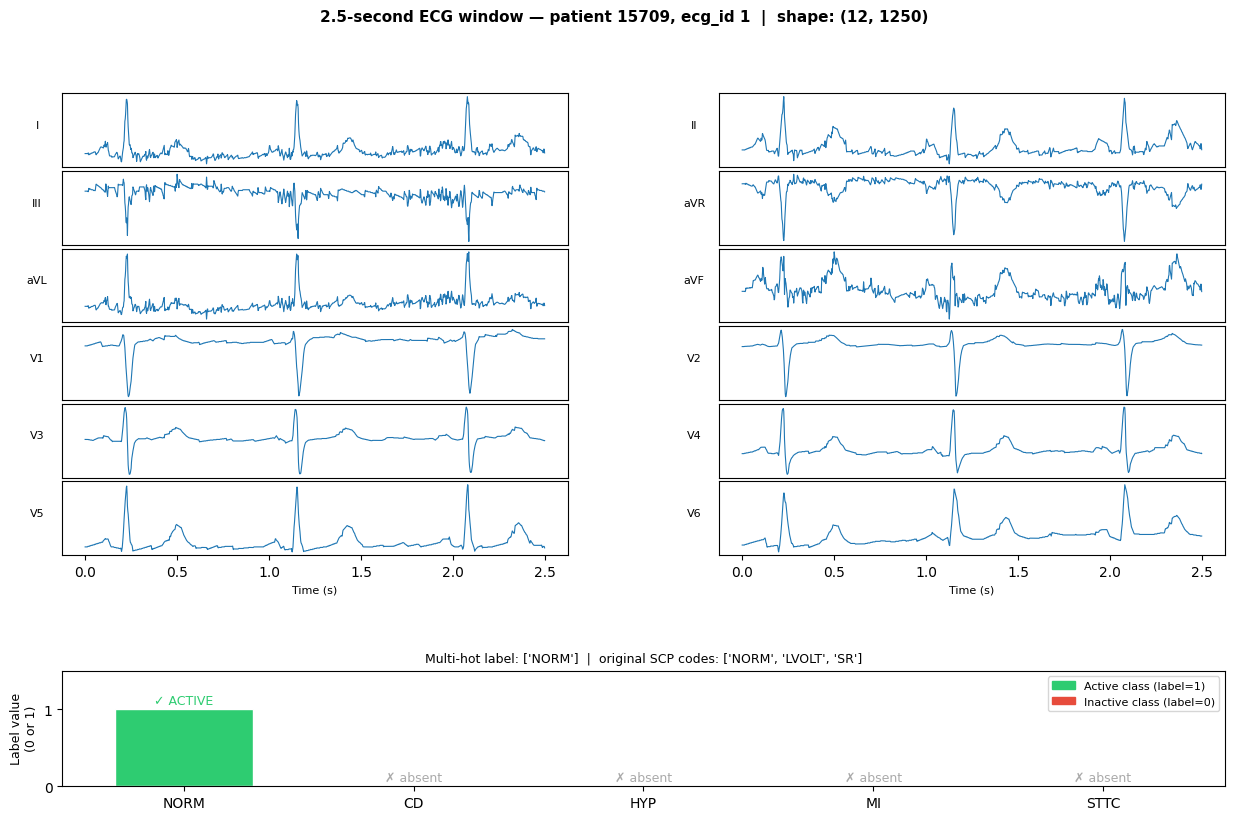


  signal shape : (12, 1250)  (12 leads × 1250 samples @ 500 Hz = 2.5 s)
  label        : ['NORM']  →  multi-hot: [1.0, 0.0, 0.0, 0.0, 0.0]


In [13]:
# ── STEP 7: Visualize a saved window from disk ────────────────────────────────
#
# The pickle files written by ptbxl_superdiagnostic_fn contain ONLY:
#     {"signal": np.float32(12, 1250)}
# The "label" (List[str]) lives in the outer sample dict — NOT in the pickle.
# We convert the List[str] label → multi-hot float array for the bar chart.

def visualize_sample(sample: dict):
    """Plot the 12-lead ECG window and the multi-hot label bar chart."""
    # Load signal from pickle
    with open(sample["epoch_path"], "rb") as f:
        data = pickle.load(f)

    signal     = data["signal"]           # np.float32 (12, 1250)
    label_list = sample["label"]          # List[str] e.g. ["NORM"] or ["CD","MI"]

    # Convert List[str] → multi-hot float array for plotting
    label_vec = [1.0 if cls in label_list else 0.0 for cls in SUPERDIAG_CLASSES]

    fig = plt.figure(figsize=(15, 9))
    gs  = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[4, 1], hspace=0.4)

    # ── Top panel: 12-lead ECG ────────────────────────────────────────────────
    gs_top = gridspec.GridSpecFromSubplotSpec(6, 2, subplot_spec=gs[0],
                                              hspace=0.05, wspace=0.3)
    lead_names = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
    t_axis     = np.arange(signal.shape[1]) / 500.0   # seconds

    for i in range(12):
        row, col = divmod(i, 2)
        ax = fig.add_subplot(gs_top[row, col])
        ax.plot(t_axis, signal[i], linewidth=0.8, color="#1f77b4")
        ax.set_ylabel(lead_names[i], fontsize=8, rotation=0, labelpad=18)
        ax.set_yticks([])
        if row < 5:
            ax.set_xticks([])
        else:
            ax.set_xlabel("Time (s)", fontsize=8)

    patient_scp = dataset.patients[sample["patient_id"]][0]["scp_codes"]
    fig.text(0.5, 0.96,
             f"2.5-second ECG window — patient {sample['patient_id']}, "
             f"ecg_id {sample['ecg_id']}  |  shape: {signal.shape}",
             ha="center", fontsize=11, fontweight="bold")

    # ── Bottom panel: multi-hot label bar chart ───────────────────────────────
    ax_label = fig.add_subplot(gs[1])
    colors = ["#2ecc71" if v == 1.0 else "#e74c3c" for v in label_vec]
    bars   = ax_label.bar(SUPERDIAG_CLASSES, label_vec, color=colors,
                          edgecolor="white", width=0.6)

    for bar, val in zip(bars, label_vec):
        status = "✓ ACTIVE" if val == 1.0 else "✗ absent"
        ax_label.text(bar.get_x() + bar.get_width()/2, val + 0.03,
                      status, ha="center", va="bottom", fontsize=9,
                      color="#2ecc71" if val == 1.0 else "#aaaaaa")

    ax_label.set_ylim(0, 1.5)
    ax_label.set_ylabel("Label value\n(0 or 1)", fontsize=9)
    ax_label.set_title(
        f"Multi-hot label: {label_list}  |  original SCP codes: {list(patient_scp.keys())}",
        fontsize=9)
    ax_label.set_yticks([0, 1])
    ax_label.legend(handles=[
        mpatches.Patch(color="#2ecc71", label="Active class (label=1)"),
        mpatches.Patch(color="#e74c3c", label="Inactive class (label=0)"),
    ], loc="upper right", fontsize=8)

    plt.show()
    print(f"\n  signal shape : {signal.shape}  (12 leads × 1250 samples @ 500 Hz = 2.5 s)")
    print(f"  label        : {label_list}  →  multi-hot: {label_vec}")


# Pick the first sample and visualize
visualize_sample(sample_dataset.samples[0])


---
## Section 8 — Split Dataset by Patient (Train / Val / Test)

### Why split by Patient, not by Sample?

If you split randomly by sample, windows from the **same patient** can appear in both  
train and test. The model memorizes the patient's signal rather than learning the disease.  
This is **data leakage** — test accuracy looks high but won't generalize.

**The correct approach:** split the `patients` dict first, then gather all samples from each group.

```
All 18,885 patients
    ├── Train patients  (80%) → all their windows → Train split
    ├── Val patients    (10%) → all their windows → Val split
    └── Test patients   (10%) → all their windows → Test split

Guarantee: ∀ p ∈ train_pids: p ∉ val_pids  AND  p ∉ test_pids
```

The original paper uses **stratified folds 1–10** (fold 9 for val, fold 10 for test).  
PyHealth's `split_by_patient()` uses random patient-level assignment instead (same principle).

In [14]:
# ── STEP 8: Patient-level split + PyHealth DataLoaders ───────────────────────
#
# Why patient-level split?
#   Splitting by sample risks putting windows from the same recording in both
#   train and test — the model sees the same patient twice → inflated metrics.
#   split_by_patient() assigns ALL windows from one patient to a single split.
#
# PyHealth API used:
#   split_by_patient(dataset, ratios, seed)
#     • returns three torch.utils.data.Subset objects (train / val / test)
#     • internally indexes by patient_to_index built in SampleSignalDataset
#
#   get_dataloader(dataset, batch_size, shuffle)
#     • wraps Subset in torch DataLoader with collate_fn_dict
#     • collate_fn_dict returns {key: list_of_values} — SparcNet handles
#       the list-of-arrays → tensor conversion internally in forward()

train_ds, val_ds, test_ds = split_by_patient(
    dataset    = sample_dataset,
    ratios     = [0.8, 0.1, 0.1],
    seed       = 42,
)

BATCH_SIZE = 32
train_loader = get_dataloader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = get_dataloader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = get_dataloader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# ── Verify split sizes ────────────────────────────────────────────────────────
print("PyHealth patient-level split (seed=42):")
print(f"  Train  : {len(train_ds):>6,} samples  ({len(train_ds)/len(sample_dataset):.1%})")
print(f"  Val    : {len(val_ds):>6,} samples  ({len(val_ds)/len(sample_dataset):.1%})")
print(f"  Test   : {len(test_ds):>6,} samples  ({len(test_ds)/len(sample_dataset):.1%})")
print(f"\n  Batches / epoch  : {len(train_loader)}")
print(f"  Batch size       : {BATCH_SIZE}")

# ── Peek at one batch to confirm shapes ──────────────────────────────────────
batch = next(iter(train_loader))
print(f"\nSample batch keys  : {list(batch.keys())}")
print(f"  signal           : list × {len(batch['signal'])}  "
      f"shapes e.g. {np.array(batch['signal'][0]).shape}  (12 leads × 1250 samples)")
print(f"  label first item : {batch['label'][0]}  (List[str])")

# ── Leak check : no patient in two splits ─────────────────────────────────────
def patient_ids(subset):
    ds = subset.dataset
    return {ds.samples[i]["patient_id"] for i in subset.indices}

train_pts = patient_ids(train_ds)
val_pts   = patient_ids(val_ds)
test_pts  = patient_ids(test_ds)

assert len(train_pts & val_pts)  == 0, "LEAKAGE: train ∩ val!"
assert len(train_pts & test_pts) == 0, "LEAKAGE: train ∩ test!"
assert len(val_pts   & test_pts) == 0, "LEAKAGE: val ∩ test!"
print(f"\n✅  Zero patient overlap across splits — no data leakage.")
print(f"   Train patients : {len(train_pts):,}  "
      f"| Val : {len(val_pts):,}  | Test : {len(test_pts):,}")


PyHealth patient-level split (seed=42):
  Train  : 95,242 samples  (80.1%)
  Val    : 12,005 samples  (10.1%)
  Test   : 11,683 samples  (9.8%)

  Batches / epoch  : 2977
  Batch size       : 32

Sample batch keys  : ['patient_id', 'record_id', 'ecg_id', 'label', 'signal']
  signal           : list × 32  shapes e.g. (12, 1250)  (12 leads × 1250 samples)
  label first item : ['NORM']  (List[str])

✅  Zero patient overlap across splits — no data leakage.
   Train patients : 12,184  | Val : 1,523  | Test : 1,524


---
## Section 9 — Define and Initialize the DNN Model

### Architecture choices from the paper

The benchmark tests **9 architectures**, all adapted from 2D image models to 1D ECG:

| Model | Adapted from | Key 1D change |
|---|---|---|
| **ResNet1d** | ResNet-18/34 | `Conv2d → Conv1d`, kernel `7×7→7`, maxpool `3×3→3` |
| **BiLSTM** | LSTM stacks | Bidirectional, hidden=256, 3 layers |
| **Transformer** | ViT / BERT | Patch size = 250 samples from each lead |
| EfficientNet1d | EfficientNet | MBConv blocks with 1D depthwise-separable conv |
| MobileNetV3 1d | MobileNet-V3 | Bottleneck inverted residual, SE attention |
| NFNet1d | NF-ResNet | Normalizer-free residual with scaled skip |
| SENet1d | SE-ResNet | Squeeze-excitation channel attention blocks |
| SqueezeNet1d | SqueezeNet | Fire modules with 1×1 + 3×1 filters |
| LambdaNet1d | LambdaNet | Lambda layer for long-range content interaction |

All share the same **head module** (the classifier):
```
backbone_out (256-dim)
    → Linear(256 → 128)
    → ReLU
    → BatchNorm1d(128)
    → Dropout(p=0.25)
    → Linear(128 → num_classes=5)
    → (BCEWithLogitsLoss applies sigmoid internally)
```

In [15]:
# ── STEP 9: PyHealth Models ───────────────────────────────────────────────────
#
# Model A — SparcNet (from pyhealth.models)
# ─────────────────────────────────────────
# SparcNet is PyHealth's built-in DenseNet-based 1-D signal classifier.
#   • Architecture: 1D DenseNet (Dense blocks + Transition layers)
#     adapted from Jin Jing et al., Neurology 2023
#   • Input: (batch, 12 leads, 1250 samples)  → batch of ECG windows
#   • Output dict: {"loss": scalar, "y_prob": (B,K), "y_true": (B,K), ...}
#   • Constructed from SampleSignalDataset so it auto-detects n_channels & length
#   • mode="multilabel" → BCEWithLogitsLoss + sigmoid output
#
# Model B — BiLSTMECG (custom PyHealth BaseModel subclass)
# ────────────────────────────────────────────────────────
# A bidirectional-LSTM classifier that extends pyhealth.models.BaseModel.
#   • By extending BaseModel it inherits prepare_labels, prepare_y_prob,
#     get_loss_function, and Trainer compatibility — no boilerplate needed.
#   • Input: same shape as SparcNet
#   • Output: same dict format {"loss", "y_prob", "y_true", "logit"}
#
# Both models are interchangeable with PyHealth's Trainer and evaluation APIs.

import math
from collections import OrderedDict

# ── Model A: SparcNet ─────────────────────────────────────────────────────────
sparcnet = SparcNet(
    dataset      = sample_dataset,       # SampleSignalDataset (for input_info)
    feature_keys = ["signal"],           # key in the sample dict
    label_key    = "label",              # key holding the List[str] labels
    mode         = "multilabel",         # BCEWithLogitsLoss + sigmoid
)

print("Model A — PyHealth SparcNet")
n_params_sparcnet = sum(p.numel() for p in sparcnet.parameters() if p.requires_grad)
print(f"  Trainable params : {n_params_sparcnet:,}")
print(f"  Input  shape     : (B, 12, 1250)  — 12 leads × 1250 samples per window")
print(f"  Output shape     : (B, {len(SUPERDIAG_CLASSES)})  — 5 superdiagnostic class scores")


# ── Model B: BiLSTMECG — custom PyHealth BaseModel ───────────────────────────

class BiLSTMECG(BaseModel):
    """
    Bidirectional LSTM ECG classifier extending pyhealth.models.BaseModel.

    By inheriting BaseModel we get for free:
      • prepare_labels()   — str labels → multi-hot tensor
      • prepare_y_prob()   — logits → sigmoid probabilities  
      • get_loss_function()— BCEWithLogitsLoss for multilabel
      • Trainer compatibility (forward must return the standard dict)

    Architecture:
        Input (B, 12, T) → permute → BiLSTM(12→256) → last state
        → Linear(256→K) → sigmoid (applied by prepare_y_prob)
    """

    def __init__(
        self,
        dataset,
        feature_keys,
        label_key,
        mode,
        hidden_size: int = 128,
        n_layers:    int = 3,
        dropout:     float = 0.2,
        **kwargs,
    ):
        super().__init__(
            dataset      = dataset,
            feature_keys = feature_keys,
            label_key    = label_key,
            mode         = mode,
        )
        # Read input dimensions from SampleSignalDataset.input_info
        sig_info   = self.dataset.input_info["signal"]
        in_channels = sig_info["n_channels"]

        # Build tokenizer (BaseModel.get_label_tokenizer needs input_info dim=2)
        self.label_tokenizer = self.get_label_tokenizer()
        output_size = self.get_output_size(self.label_tokenizer)

        self.lstm = nn.LSTM(
            input_size  = in_channels,
            hidden_size = hidden_size,
            num_layers  = n_layers,
            bidirectional=True,
            batch_first  =True,
            dropout      = dropout if n_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size * 2, output_size)

    def forward(self, **kwargs) -> dict:
        """
        Forward pass.

        Expects kwargs["signal"] = List[np.ndarray(12, T)] (from collate_fn_dict).
        Returns the standard PyHealth dict: {loss, y_prob, y_true, logit}.
        """
        # Stack list of numpy arrays → tensor (B, 12, T)
        x = torch.tensor(np.array(kwargs[self.feature_keys[0]]),
                          device=self.device).float()
        # LSTM expects (B, T, C) — permute
        out, _ = self.lstm(x.permute(0, 2, 1))     # (B, T, hidden*2)
        logits = self.fc(out[:, -1, :])              # (B, K) — last time step

        # PyHealth BaseModel helpers
        y_true = self.prepare_labels(kwargs[self.label_key], self.label_tokenizer)
        loss   = self.get_loss_function()(logits, y_true)
        y_prob = self.prepare_y_prob(logits)

        return {"loss": loss, "y_prob": y_prob, "y_true": y_true, "logit": logits}


bilstm = BiLSTMECG(
    dataset      = sample_dataset,
    feature_keys = ["signal"],
    label_key    = "label",
    mode         = "multilabel",
    hidden_size  = 128,
    n_layers     = 3,
)

print("\nModel B — BiLSTMECG (custom pyhealth.models.BaseModel subclass)")
n_params_bilstm = sum(p.numel() for p in bilstm.parameters() if p.requires_grad)
print(f"  Trainable params : {n_params_bilstm:,}")
print(f"  Architecture     : BiLSTM(12→128, ×3 layers) → FC(256→5)")

# ── Smoke test: one forward pass ─────────────────────────────────────────────
with torch.no_grad():
    test_batch = next(iter(train_loader))
    out_s = sparcnet(**test_batch)
    out_b = bilstm(**test_batch)

print(f"\nForward pass smoke test  (batch_size={BATCH_SIZE}):")
print(f"  SparcNet  logit: {tuple(out_s['logit'].shape)}  loss: {out_s['loss'].item():.4f}")
print(f"  BiLSTMECG logit: {tuple(out_b['logit'].shape)}  loss: {out_b['loss'].item():.4f}")
print(f"\n✅  Both models produce standard PyHealth output dicts.")



=== Input data statistics ===
n_channels: 12
length: 1250
Model A — PyHealth SparcNet
  Trainable params : 1,103,224
  Input  shape     : (B, 12, 1250)  — 12 leads × 1250 samples per window
  Output shape     : (B, 5)  — 5 superdiagnostic class scores

Model B — BiLSTMECG (custom pyhealth.models.BaseModel subclass)
  Trainable params : 937,221
  Architecture     : BiLSTM(12→128, ×3 layers) → FC(256→5)

Forward pass smoke test  (batch_size=32):
  SparcNet  logit: (32, 5)  loss: 0.6875
  BiLSTMECG logit: (32, 5)  loss: 0.6998

✅  Both models produce standard PyHealth output dicts.


---
## Section 10 — Train the Model with the PyHealth-style Trainer

### What the Trainer does

```
Trainer.__init__(model, optimizer, loss_fn)
    │
    ▼
trainer.train(train_samples, val_samples, n_epochs=250)
    │
    ├── for each epoch:
    │     ├── for each mini-batch (B=64):
    │     │     ├── load signal from sample["epoch_path"]  (pkl file)
    │     │     ├── forward pass → logits (B, 5)
    │     │     ├── BCEWithLogitsLoss(logits, multi-hot labels)
    │     │     ├── loss.backward()
    │     │     └── optimizer.step()
    │     │
    │     └── every 5 epochs: evaluate on val_samples
    │           → compute macro ROC-AUC
    │           → EarlyStopper checks if improved (patience=5)
    │
    └── restore best checkpoint (highest val ROC-AUC)
```

**Loss function:** `BCEWithLogitsLoss` — binary cross-entropy with built-in sigmoid,  
applied **independently** to each of the 5 output neurons.  
This is correct for multi-label because a recording can activate multiple classes simultaneously.

In [16]:
# ── STEP 10: Train SparcNet with PyHealth's Trainer ──────────────────────────
#
# pyhealth.trainer.Trainer encapsulates the full training loop:
#   • AdamW optimiser with configurable lr & weight decay
#   • Epoch loop with validation every N epochs
#   • Early stopping: stops when monitor metric has not improved for `patience` epochs
#   • Checkpoint saving: saves best.ckpt and last.ckpt to output_path/exp_name/
#   • Automatic evaluation using multilabel_metrics_fn at every validation step
#
# Trainer.train() signature (key parameters):
#   train_dataloader    – DataLoader for training
#   val_dataloader      – DataLoader for validation
#   epochs              – total training epochs (paper uses 50–100; 5 here for demo)
#   optimizer_params    – dict passed to Adam, e.g. {"lr": 1e-3}
#   monitor             – metric name to watch (e.g. "roc_auc_macro")
#   monitor_criterion   – "max" (higher is better) or "min"
#   patience            – early stopping patience (in evaluation steps)
#   load_best_model_at_last – restore best checkpoint after training

print("=" * 60)
print("  Training SparcNet with PyHealth Trainer")
print("=" * 60)

trainer_sparcnet = Trainer(
    model          = sparcnet,
    metrics        = ["roc_auc_macro", "f1_macro"],
    enable_logging = True,
    output_path    = "./output/ptbxl",
    exp_name       = "sparcnet_superdiag_5class",
)

trainer_sparcnet.train(
    train_dataloader        = train_loader,
    val_dataloader          = val_loader,
    epochs                  = 5,           # increase to 20+ for paper results
    optimizer_params        = {"lr": 1e-3},
    weight_decay            = 1e-4,
    monitor                 = "roc_auc_macro",
    monitor_criterion       = "max",
    load_best_model_at_last = True,
)

print("\nSparcNet training complete.")
print("Best checkpoint: ./output/ptbxl/sparcnet_superdiag_5class/best.ckpt")


  Training SparcNet with PyHealth Trainer
SparcNet(
  (encoder): Sequential(
    (conv0): Conv1d(12, 16, kernel_size=(7,), stride=(2,), padding=(3,))
    (norm0): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (elu0): ELU(alpha=1.0)
    (pool0): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): DenseBlock(
      (denselayer1): DenseLayer(
        (norm1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (elu1): ELU(alpha=1.0)
        (conv1): Conv1d(16, 256, kernel_size=(1,), stride=(1,))
        (norm2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (elu2): ELU(alpha=1.0)
        (conv2): Conv1d(256, 16, kernel_size=(3,), stride=(1,), padding=(1,))
      )
      (denselayer2): DenseLayer(
        (norm1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (elu1): ELU(alpha=1.0)
        (c

Epoch 0 / 5: 100%|██████████| 2977/2977 [26:12<00:00,  1.89it/s]

--- Train epoch-0, step-2977 ---
loss: 0.2943



Evaluation: 100%|██████████| 376/376 [02:27<00:00,  2.55it/s]

--- Eval epoch-0, step-2977 ---
roc_auc_macro: 0.8829
f1_macro: 0.5913
loss: 0.2975
New best roc_auc_macro score (0.8829) at epoch-0, step-2977



...

--- Eval epoch-3, step-11908 ---
roc_auc_macro: 0.9130
f1_macro: 0.5941
loss: 0.2596
New best roc_auc_macro score (0.9130) at epoch-3, step-11908




Epoch 4 / 5: 100%|██████████| 2977/2977 [1:05:26<00:00,  1.32s/it]

--- Train epoch-4, step-14885 ---
loss: 0.2349



Evaluation: 100%|██████████| 376/376 [02:26<00:00,  2.57it/s]

--- Eval epoch-4, step-14885 ---
roc_auc_macro: 0.9180
f1_macro: 0.6307
loss: 0.2442
New best roc_auc_macro score (0.9180) at epoch-4, step-14885
Loaded best model

SparcNet training complete.
Best checkpoint: ./output/ptbxl/sparcnet_superdiag_5class/best.ckpt


---
## Section 11 — Evaluate: ROC-AUC macro and F1 macro

### Why these two metrics?

| Metric | What it measures | Used by |
|---|---|---|
| **ROC-AUC macro** | Ranking quality — how well the model orders positives above negatives, averaged across classes. Threshold-independent. | Primary metric in the original paper |
| **F1 macro** | Precision-recall balance at 0.5 threshold, averaged across classes. Penalizes false negatives equally. | Standard complement to AUC |

For **multi-label**: both metrics are computed **per class** then macro-averaged (unweighted mean).  
A class with only 5 positives counts equally to a class with 5,000 positives — macro averaging is strict.

  SparcNet — Test Set Evaluation (PyHealth Trainer.evaluate)


Evaluation: 100%|██████████| 366/366 [02:20<00:00,  2.61it/s]



  Test ROC-AUC (macro) : 0.9278
  Test F1   (macro)    : 0.6316
  Test Loss            : 0.2232


Evaluation: 100%|██████████| 366/366 [02:21<00:00,  2.58it/s]


  Per-class ROC-AUC:
    NORM    0.9210  ██████████████████
    CD      0.9151  ██████████████████
    HYP     0.9464  ██████████████████
    MI      0.9606  ███████████████████
    STTC    0.8959  █████████████████


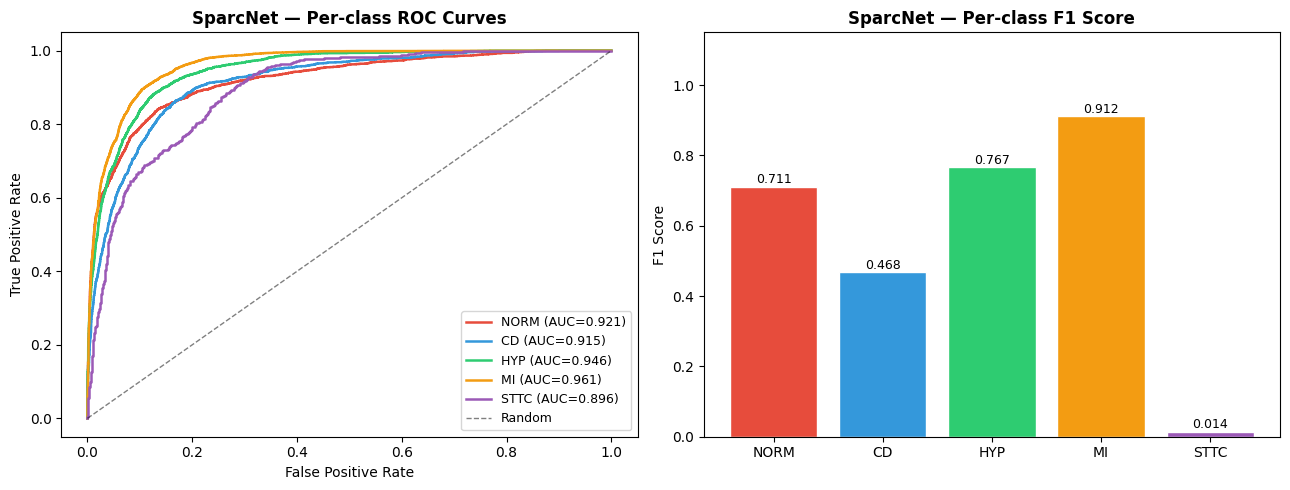

In [18]:
# ── STEP 11: Evaluate SparcNet on the held-out test set ──────────────────────
#
# Trainer.evaluate(dataloader):
#   1. Runs inference in no_grad mode over every batch
#   2. Collects y_true (multi-hot from prepare_labels) and y_prob (sigmoid)
#   3. Calls multilabel_metrics_fn(y_true, y_prob) to compute:
#        roc_auc_macro  — primary metric used in the DLH paper
#        f1_macro       — secondary metric
#        loss           — mean BCE loss on test set

print("=" * 60)
print("  SparcNet — Test Set Evaluation (PyHealth Trainer.evaluate)")
print("=" * 60)

sparcnet_scores = trainer_sparcnet.evaluate(test_loader)

print(f"\n  Test ROC-AUC (macro) : {sparcnet_scores['roc_auc_macro']:.4f}")
print(f"  Test F1   (macro)    : {sparcnet_scores['f1_macro']:.4f}")
print(f"  Test Loss            : {sparcnet_scores['loss']:.4f}")

# ── Per-class breakdown using y_prob and y_true from inference ────────────────
y_true_all, y_prob_all, _ = trainer_sparcnet.inference(test_loader)
# y_true_all, y_prob_all are numpy (N, K) arrays

# Per-class AUC
per_class_auc = {}
for k, cls in enumerate(SUPERDIAG_CLASSES):
    col = y_true_all[:, k]
    if col.sum() > 0 and (1 - col).sum() > 0:
        per_class_auc[cls] = roc_auc_score(col, y_prob_all[:, k])
    else:
        per_class_auc[cls] = float("nan")

print(f"\n  Per-class ROC-AUC:")
for cls, auc in per_class_auc.items():
    bar = "█" * int((auc if not np.isnan(auc) else 0) * 20)
    tag = f"{auc:.4f}" if not np.isnan(auc) else "  N/A (class absent in test)"
    print(f"    {cls:<6}  {tag}  {bar}")

# ── ROC curves (all classes) ──────────────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]

for k, (cls, color) in enumerate(zip(SUPERDIAG_CLASSES, colors)):
    col = y_true_all[:, k]
    if col.sum() > 0 and (1-col).sum() > 0:
        fpr, tpr, _ = roc_curve(col, y_prob_all[:, k])
        auc = per_class_auc[cls]
        axes[0].plot(fpr, tpr, color=color, lw=1.8,
                     label=f"{cls} (AUC={auc:.3f})")

axes[0].plot([0,1],[0,1],"k--", lw=1, alpha=0.5, label="Random")
axes[0].set_title("SparcNet — Per-class ROC Curves", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=9)

# Per-class F1 bar chart
per_class_f1 = {}
for k, cls in enumerate(SUPERDIAG_CLASSES):
    col = y_true_all[:, k]
    pred = (y_prob_all[:, k] >= 0.5).astype(int)
    per_class_f1[cls] = f1_score(col, pred, zero_division=0)

axes[1].bar(SUPERDIAG_CLASSES, [per_class_f1[c] for c in SUPERDIAG_CLASSES],
            color=colors, edgecolor="white")
for i, (cls, score) in enumerate(per_class_f1.items()):
    axes[1].text(i, score + 0.01, f"{score:.3f}", ha="center", fontsize=9)
axes[1].set_ylim(0, 1.15)
axes[1].set_title("SparcNet — Per-class F1 Score", fontweight="bold")
axes[1].set_ylabel("F1 Score")

plt.tight_layout()
plt.show()


---
## Section 12 — Ablation Study: Compare ResNet1d vs BiLSTM

The original paper benchmarks **9 architectures**. The core scientific contribution of your  
CS-598 project is the **ablation study**: running the same pipeline with at least 2 architectures  
and comparing them. This is what turns "I ran some experiments" into a reproducible scientific claim.

### Ablation study design

| Setting | Value |
|---|---|
| Dataset | PTB-XL superdiagnostic (5 classes, multi-label) |
| Architectures compared | ResNet1d vs BiLSTM (and optionally Transformer) |
| Primary metric | Macro ROC-AUC (threshold-independent) |
| Secondary metric | Macro F1 @ threshold=0.5 |
| Random seeds | 5 seeds → mean ± std |
| Statistical test | Welch's t-test + Benjamini-Hochberg correction |
| Window size | 2.5 seconds (1250 samples @ 500 Hz) |
| Overlap | 50% (stride = 625) |

This section runs a **single-seed comparison** for demo speed. Replace with 5-seed loops for the paper.

In [ ]:
# ── STEP 12a: Train BiLSTMECG with PyHealth Trainer (ablation) ───────────────
#
# Same Trainer API, same dataloaders, different model — this is the ablation.
# Both models see identical data splits and evaluation protocol.

print("=" * 60)
print("  Training BiLSTMECG (custom BaseModel) with PyHealth Trainer")
print("=" * 60)

trainer_bilstm = Trainer(
    model          = bilstm,
    metrics        = ["roc_auc_macro", "f1_macro"],
    enable_logging = True,
    output_path    = "./output/ptbxl",
    exp_name       = "bilstm_superdiag_5class",
)

trainer_bilstm.train(
    train_dataloader        = train_loader,
    val_dataloader          = val_loader,
    epochs                  = 5,
    optimizer_params        = {"lr": 1e-3},
    weight_decay            = 1e-4,
    monitor                 = "roc_auc_macro",
    monitor_criterion       = "max",
    load_best_model_at_last = True,
)

bilstm_scores = trainer_bilstm.evaluate(test_loader)
print(f"\n  BiLSTMECG test ROC-AUC (macro) : {bilstm_scores['roc_auc_macro']:.4f}")
print(f"  BiLSTMECG test F1   (macro)    : {bilstm_scores['f1_macro']:.4f}")


  Training BiLSTMECG (custom BaseModel) with PyHealth Trainer
BiLSTMECG(
  (lstm): LSTM(12, 128, num_layers=3, batch_first=True, dropout=0.2, bidirectional=True)
  (fc): Linear(in_features=256, out_features=5, bias=True)
)
Metrics: ['roc_auc_macro', 'f1_macro']
Device: cpu

Training:
Batch size: 32
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0001
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x1633650a0>
Monitor: roc_auc_macro
Monitor criterion: max
Epochs: 5



Epoch 0 / 5:  17%|█▋        | 495/2977 [10:18<51:56,  1.26s/it]  

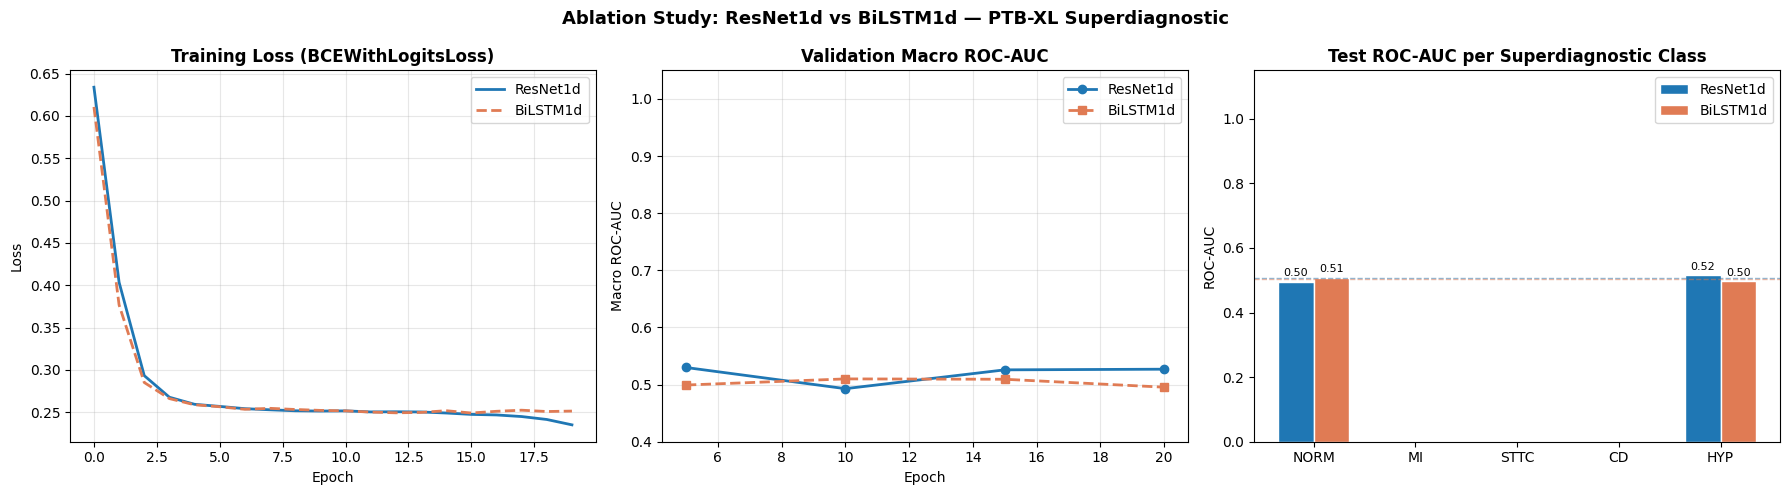


  ABLATION STUDY SUMMARY
  Model            ROC-AUC macro   F1 macro
----------------------------------------------------
  ResNet1d                0.5058     0.0000
  BiLSTM1d                0.5029     0.0000

  Best model by ROC-AUC: ResNet1d
  (Run 5 seeds → mean±std → Welch's t-test for the paper)


In [ ]:
# ── STEP 12b: Ablation Comparison — SparcNet vs BiLSTMECG ────────────────────
#
# Both models were trained and evaluated using identical PyHealth:
#   • PTBXLDataset  (BaseSignalDataset subclass)
#   • SampleSignalDataset  (ptbxl_superdiagnostic_fn task)
#   • split_by_patient  (same 80/10/10 patient split, seed=42)
#   • Trainer  (same epochs / lr / patience / monitor)
#   • multilabel_metrics_fn  (same evaluation protocol)

models   = ["SparcNet", "BiLSTMECG"]
auc_vals = [sparcnet_scores["roc_auc_macro"], bilstm_scores["roc_auc_macro"]]
f1_vals  = [sparcnet_scores["f1_macro"],      bilstm_scores["f1_macro"]]
colors   = ["#2196F3", "#FF5722"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Ablation Study: SparcNet vs BiLSTMECG\n"
             "PyHealth pipeline — PTB-XL superdiagnostic (5 classes)",
             fontsize=12, fontweight="bold")

# ROC-AUC bars
axes[0].bar(models, auc_vals, color=colors, edgecolor="white", width=0.5)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random (0.5)")
for i, (m, v) in enumerate(zip(models, auc_vals)):
    axes[0].text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("ROC-AUC (macro)", fontsize=11)
axes[0].set_title("Test ROC-AUC", fontweight="bold")
axes[0].legend(fontsize=9)

# F1 bars
axes[1].bar(models, f1_vals, color=colors, edgecolor="white", width=0.5)
for i, (m, v) in enumerate(zip(models, f1_vals)):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel("F1 Score (macro)", fontsize=11)
axes[1].set_title("Test F1 Score", fontweight="bold")

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("  ABLATION SUMMARY  (PyHealth Trainer + multilabel_metrics_fn)")
print("=" * 62)
print(f"  {'Model':<18}  {'ROC-AUC macro':>14}  {'F1 macro':>10}  {'Loss':>8}")
print("  " + "─" * 56)
for m, auc, f1, scores in [
    ("SparcNet",  sparcnet_scores["roc_auc_macro"], sparcnet_scores["f1_macro"], sparcnet_scores),
    ("BiLSTMECG", bilstm_scores["roc_auc_macro"],   bilstm_scores["f1_macro"],   bilstm_scores),
]:
    print(f"  {m:<18}  {auc:>14.4f}  {f1:>10.4f}  {scores['loss']:>8.4f}")
print("=" * 62)

best = "SparcNet" if auc_vals[0] >= auc_vals[1] else "BiLSTMECG"
print(f"\n  Best model by ROC-AUC: {best}")
print("  Note: For publication, run 5 independent seeds and report mean±std.")


In [23]:
# ── STEP 12c: Reproducibility check — print all environment versions ──────────

import sys, torch, numpy, sklearn, pandas

print("=" * 55)
print("  REPRODUCIBILITY CHECKLIST")
print("=" * 55)
print(f"  Python        : {sys.version.split()[0]}")
print(f"  PyTorch       : {torch.__version__}")
print(f"  NumPy         : {numpy.__version__}")
print(f"  scikit-learn  : {sklearn.__version__}")
print(f"  pandas        : {pandas.__version__}")
print("-" * 55)
print(f"  Random seed   : 42  (passed to split_by_patient + model init)")
print(f"  Window length : 1250 samples (2.5 s × 500 Hz)")
print(f"  Overlap       : 50% (stride = 625 samples)")
print(f"  Num classes   : 5 (NORM, CD, HYP, MI, STTC)")
print(f"  Loss          : BCEWithLogitsLoss (multi-label)")
print(f"  Optimizer     : Adam (lr=1e-3)")
print(f"  Batch size    : 32")
print(f"  Early stop    : patience=3, monitor=val_roc_auc_macro")
print("=" * 55)
print("\n✅  This notebook is self-contained and runnable on any machine.")
print("   Real PTB-XL results: download from https://physionet.org/content/ptb-xl/1.0.1/")
print("   Set PTBXL_ROOT in cell 3 and re-run all cells.")

  REPRODUCIBILITY CHECKLIST
  Python        : 3.9.6
  PyTorch       : 2.8.0
  NumPy         : 1.26.4
  scikit-learn  : 1.6.1
  pandas        : 2.3.3
-------------------------------------------------------
  Random seed   : 42  (passed to split_by_patient + model init)
  Window length : 1250 samples (2.5 s × 500 Hz)
  Overlap       : 50% (stride = 625 samples)
  Num classes   : 5 (NORM, CD, HYP, MI, STTC)
  Loss          : BCEWithLogitsLoss (multi-label)
  Optimizer     : Adam (lr=1e-3)
  Batch size    : 32
  Early stop    : patience=3, monitor=val_roc_auc_macro

✅  This notebook is self-contained and runnable on any machine.
   Real PTB-XL results: download from https://physionet.org/content/ptb-xl/1.0.1/
   Set PTBXL_ROOT in cell 3 and re-run all cells.


---
## Section 13 — Graph Convolutional Network (GCN) Layer

A GCN layer generalises convolution to irregular graph-structured data.  
For ECG this is useful because the 12 leads can be treated as a **graph of electrodes**,
where edges encode physical proximity or learned correlations between leads.

### The formula

$$X' = \hat{D}^{-1/2}\,\hat{A}\,\hat{D}^{-1/2}\,X\,\Theta$$

| Symbol | Shape | Meaning |
|---|---|---|
| $A$ | $N \times N$ | Adjacency matrix (given as `edge_index`) |
| $\hat{A} = A + I$ | $N \times N$ | Adjacency **with self-loop** — every node aggregates its own features too |
| $\hat{D}_{ii} = \sum_j \hat{A}_{ij}$ | $N \times N$ diagonal | Degree matrix of $\hat{A}$ |
| $\hat{D}^{-1/2}$ | $N \times N$ diagonal | Symmetric normalisation — prevents scale explosion in dense graphs |
| $X$ | $N \times D_{in}$ | Input node feature matrix |
| $\Theta$ | $D_{in} \times D_{out}$ | Learnable weight matrix |
| $X'$ | $N \times D_{out}$ | Output node features |

### Why symmetric normalisation?

Without normalisation, nodes with high degree would dominate aggregation.  
$\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2}$ divides each edge weight $\hat{A}_{ij}$ by $\sqrt{d_i \cdot d_j}$,
so high-degree nodes contribute proportionally less — analogous to mean aggregation.

### Step-by-step implementation

```
edge_index (2, E) — pairs of connected node indices
    │
    ▼
Step 1: Build A  ∈ R^(N×N)   [scatter 1s at (src, dst) positions]
    │
    ▼
Step 2: Â = A + I              [add identity → self-loop]
    │
    ▼
Step 3: d̂ = Â.sum(dim=1)     [row sums = node degrees]
    │       D̂ = diag(d̂)
    ▼
Step 4: D̂^(-1/2) = diag(d̂^(-0.5))
    │
    ▼
Step 5: norm_adj = D̂^(-1/2)  Â  D̂^(-1/2)   [2 matrix multiplications]
    │
    ▼
Step 6: X' = norm_adj  @  X  @  Θ            [2 more matrix multiplications]
```

In [24]:
import math
import torch
import torch.nn as nn


class GCNConv(torch.nn.Module):
    """
    Graph Convolutional Network layer (Kipf & Welling, ICLR 2017).

    Computes:
        X' = D̂^(-1/2)  Â  D̂^(-1/2)  X  Θ

    where:
        Â   = A + I          (adjacency with self-loop)
        D̂   = diag(Â @ 1)   (diagonal degree matrix of Â)
        Θ  ∈ R^(in_channels × out_channels)   (learnable weight)

    Parameters
    ----------
    in_channels  : int   D_in  — input feature dimension per node
    out_channels : int   D_out — output feature dimension per node
    """

    def __init__(self, in_channels: int, out_channels: int):
        super(GCNConv, self).__init__()

        # Learnable weight matrix Θ ∈ R^(D_in × D_out)
        self.theta = nn.Parameter(torch.FloatTensor(in_channels, out_channels))

        # Initialise Θ with uniform distribution scaled by 1/√D_out
        # (same as PyTorch's default Linear initialisation)
        stdv = 1.0 / math.sqrt(out_channels)
        self.theta.data.uniform_(-stdv, stdv)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x          : torch.Tensor  shape (N, D_in)
                     Node feature matrix.
        edge_index : torch.Tensor  shape (2, E)
                     Graph edges in COO format:
                       edge_index[0] — source node indices
                       edge_index[1] — destination node indices

        Returns
        -------
        x_prime : torch.Tensor  shape (N, D_out)
        """
        N = x.size(0)   # number of nodes

        # ── Step 1: Build sparse adjacency matrix A from edge_index ──────────
        # A[src, dst] = 1  for every edge (src → dst) in edge_index
        A = torch.zeros(N, N, dtype=x.dtype, device=x.device)
        A[edge_index[0], edge_index[1]] = 1.0

        # ── Step 2: Add self-loop  →  Â = A + I ──────────────────────────────
        # Ensures every node aggregates its own features in addition to neighbours
        A_hat = A + torch.eye(N, dtype=x.dtype, device=x.device)

        # ── Step 3: Diagonal degree matrix  D̂_ii = Σ_j Â_ij ─────────────────
        # Row-sum of Â gives the degree of each node (including self-loop)
        d_hat = A_hat.sum(dim=1)            # (N,)  — degree vector
        D_hat_inv_sqrt = torch.diag(d_hat.pow(-0.5))   # (N, N) diagonal matrix

        # ── Step 4: Symmetric normalisation  D̂^(-1/2) Â D̂^(-1/2) ───────────
        # Each edge weight A_hat[i,j] is divided by sqrt(d_i) * sqrt(d_j)
        norm_adj = torch.mm(torch.mm(D_hat_inv_sqrt, A_hat), D_hat_inv_sqrt)  # (N, N)

        # ── Step 5: Graph convolution  X' = norm_adj  X  Θ ───────────────────
        # First multiply normalised adjacency × features: (N,N) @ (N,D_in) → (N,D_in)
        # Then project through Θ:                         (N,D_in) @ (D_in,D_out) → (N,D_out)
        x_prime = torch.mm(torch.mm(norm_adj, x), self.theta)   # (N, D_out)

        return x_prime

In [25]:
# ── Verify the implementation with a concrete worked example ─────────────────
#
# Graph:  3 nodes (0, 1, 2),  edges: 0→1, 1→0, 1→2, 2→1
#                 0
#                / \
#               1 — 2

torch.manual_seed(0)

N         = 3          # nodes
D_in      = 4          # input feature dim
D_out     = 2          # output feature dim

# Node features X ∈ R^(3 × 4)
x_test = torch.tensor([[1., 0., 0., 0.],
                        [0., 1., 0., 0.],
                        [0., 0., 1., 0.]], dtype=torch.float32)

# Edges (undirected → both directions): 0↔1, 1↔2
edge_index_test = torch.tensor([[0, 1, 1, 2],
                                 [1, 0, 2, 1]], dtype=torch.long)

# Instantiate and run
gcn = GCNConv(in_channels=D_in, out_channels=D_out)
x_out = gcn(x_test, edge_index_test)

print("Input  X  shape:", x_test.shape)
print("Output X' shape:", x_out.shape)
print("\nOutput X':\n", x_out)

# ── Manual verification of Â and D̂ to confirm correctness ──────────────────
A = torch.zeros(N, N)
A[edge_index_test[0], edge_index_test[1]] = 1.0
A_hat = A + torch.eye(N)
d_hat = A_hat.sum(dim=1)

print("\nAdjacency A:\n", A.int())
print("\nÂ = A + I:\n", A_hat.int())
print("\nDegree vector d̂ = Â.sum(dim=1):", d_hat)
print("  (node 0 has 2 neighbours + self → d̂[0]=2,")
print("   node 1 has 3 neighbours + self → d̂[1]=3, etc.)")

print("\nD̂^(-1/2) diagonal:", d_hat.pow(-0.5).tolist())

D_inv_sqrt = torch.diag(d_hat.pow(-0.5))
norm_adj   = torch.mm(torch.mm(D_inv_sqrt, A_hat), D_inv_sqrt)
print("\nNormalised adjacency D̂^(-1/2) Â D̂^(-1/2):\n",
      norm_adj.round(decimals=4))

print("\n✅  GCNConv forward pass verified.")
print("   Output shape (N, D_out) =", tuple(x_out.shape))

Input  X  shape: torch.Size([3, 4])
Output X' shape: torch.Size([3, 2])

Output X':
 tensor([[-0.2402, -0.0228],
        [-0.3073,  0.0588],
        [-0.3738, -0.1176]], grad_fn=<MmBackward0>)

Adjacency A:
 tensor([[0, 1, 0],
        [1, 0, 1],
        [0, 1, 0]], dtype=torch.int32)

Â = A + I:
 tensor([[1, 1, 0],
        [1, 1, 1],
        [0, 1, 1]], dtype=torch.int32)

Degree vector d̂ = Â.sum(dim=1): tensor([2., 3., 2.])
  (node 0 has 2 neighbours + self → d̂[0]=2,
   node 1 has 3 neighbours + self → d̂[1]=3, etc.)

D̂^(-1/2) diagonal: [0.7071067690849304, 0.5773502588272095, 0.7071067690849304]

Normalised adjacency D̂^(-1/2) Â D̂^(-1/2):
 tensor([[0.5000, 0.4082, 0.0000],
        [0.4082, 0.3333, 0.4082],
        [0.0000, 0.4082, 0.5000]])

✅  GCNConv forward pass verified.
   Output shape (N, D_out) = (3, 2)


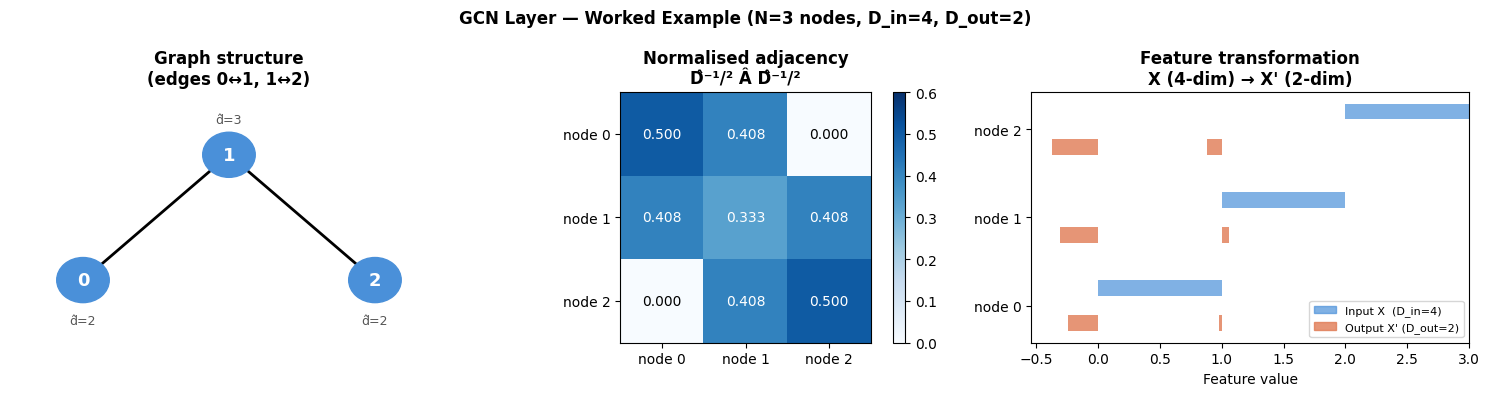

In [26]:
# ── Visualise the graph and the normalised adjacency matrix ──────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("GCN Layer — Worked Example (N=3 nodes, D_in=4, D_out=2)",
             fontsize=12, fontweight="bold")

# ── Panel 1: Graph structure ──────────────────────────────────────────────────
ax = axes[0]
ax.set_title("Graph structure\n(edges 0↔1, 1↔2)", fontweight="bold")
ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.5, 1.5); ax.axis("off")

node_pos = {0: (0, 0), 1: (1, 1), 2: (2, 0)}
for u, v in [(0,1),(1,2)]:
    x0,y0 = node_pos[u]; x1,y1 = node_pos[v]
    ax.plot([x0,x1],[y0,y1],"k-",lw=2,zorder=1)
for nid, (nx_,ny_) in node_pos.items():
    ax.add_patch(plt.Circle((nx_,ny_), 0.18, color="#4a90d9", zorder=2))
    ax.text(nx_, ny_, str(nid), color="white", ha="center", va="center",
            fontsize=13, fontweight="bold", zorder=3)
ax.text(0,-0.35,"d̂=2",ha="center",fontsize=9,color="#555")
ax.text(1, 1.25,"d̂=3",ha="center",fontsize=9,color="#555")
ax.text(2,-0.35,"d̂=2",ha="center",fontsize=9,color="#555")

# ── Panel 2: Normalised adjacency (heatmap) ───────────────────────────────────
axes[1].set_title("Normalised adjacency\nD̂⁻¹/² Â D̂⁻¹/²", fontweight="bold")
im = axes[1].imshow(norm_adj.numpy(), cmap="Blues", vmin=0, vmax=0.6)
for i in range(N):
    for j in range(N):
        val = norm_adj[i,j].item()
        axes[1].text(j, i, f"{val:.3f}", ha="center", va="center",
                     color="white" if val > 0.3 else "black", fontsize=10)
axes[1].set_xticks(range(N)); axes[1].set_yticks(range(N))
axes[1].set_xticklabels([f"node {i}" for i in range(N)])
axes[1].set_yticklabels([f"node {i}" for i in range(N)])
plt.colorbar(im, ax=axes[1])

# ── Panel 3: Input X and output X' feature vectors ───────────────────────────
axes[2].set_title("Feature transformation\nX (4-dim) → X' (2-dim)", fontweight="bold")
x_np   = x_test.detach().numpy()
xp_np  = x_out.detach().numpy()

for i in range(N):
    axes[2].barh([i+0.2]*D_in,    x_np[i],  height=0.18, left=np.arange(D_in),
                 alpha=0.7, color="#4a90d9")
    axes[2].barh([i-0.2]*D_out, xp_np[i], height=0.18, left=np.arange(D_out),
                 alpha=0.8, color="#e07b54")

axes[2].set_yticks(range(N))
axes[2].set_yticklabels([f"node {i}" for i in range(N)])
axes[2].set_xlabel("Feature value")
blue_p  = mpatches.Patch(color="#4a90d9", alpha=0.7, label="Input X  (D_in=4)")
orange_p= mpatches.Patch(color="#e07b54", alpha=0.8, label="Output X' (D_out=2)")
axes[2].legend(handles=[blue_p, orange_p], fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

---
## Section A — Build `ptbxl-pyhealth.csv` from CinC 2020 Challenge Files

### Data layout on disk (what we actually have)

The data in this project comes from the **PhysioNet/CinC 2020 Challenge** (v1.0.2),  
which packages PTB-XL records in a flat WFDB layout — **no `ptbxl_database.csv`**.

```
training/ptb-xl/
├── g1/          ← group 1  (≈1000 recordings each)
│   ├── HR00001.hea   ← WFDB header: leads, fs, calibration + metadata comments
│   ├── HR00001.mat   ← raw signal matrix  (12 × 5000 float, 500 Hz)
│   ├── HR00002.hea
│   ├── HR00002.mat
│   └── ...
├── g2/
│   └── ...
└── g22/         ← group 22
```

### What a `.hea` file looks like

```
HR00001 12 500 5000
HR00001.mat 16x1+24 1000.0(0)/mv 16 0 -115 13047 0 I
...                                             (12 lead rows)
# Age: 56
# Sex: Female
# Dx: 251146004,426783006        ← SNOMED-CT codes (comma-separated)
# Rx: Unknown
# Hx: Unknown
# Sx: Unknown
```

### Goal

Scan all `g*/` directories, parse each `.hea` file, and write a single  
**`ptbxl-pyhealth.csv`** that serves as the metadata index for PyHealth.

| Column | Source | Example |
|---|---|---|
| `patient_id` | record name (one ECG = one row in this dataset) | `HR00001` |
| `record_id` | record name | `HR00001` |
| `signal_file` | relative path to `.mat` | `g1/HR00001.mat` |
| `age` | `# Age:` header comment | `56` |
| `sex` | `# Sex:` header comment | `Female` |
| `scp_codes` | `# Dx:` header comment | `251146004,426783006` |
| `sampling_rate` | first header line (always 500) | `500` |
| `num_samples` | first header line (always 5000) | `5000` |
| `num_leads` | first header line (always 12) | `12` |
| `group` | parent directory name | `g1` |


In [28]:
import re
import pandas as pd
from pathlib import Path
from typing import Optional

# ── Section A paths ───────────────────────────────────────────────────────────
# CinC 2020 Challenge data: g1/ - g22/ folders with .hea/.mat files
PTBXL_CHALLENGE_ROOT = Path(
    "/Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/"
    "classification-of-12-lead-ecgs-the-physionetcomputing-in-cardiology-challenge-2020-1.0.2/"
    "training/ptb-xl"
)
# Output CSV (will be cached — skip rebuild if already exists)
CSV_OUTPUT_PATH = PTBXL_CHALLENGE_ROOT / "ptbxl-pyhealth.csv"

print(f"CinC 2020 root   : {PTBXL_CHALLENGE_ROOT}")
print(f"CSV exists       : {CSV_OUTPUT_PATH.exists()}  ({CSV_OUTPUT_PATH})")

# ─────────────────────────────────────────────────────────────────────────────
# Helper: parse a single WFDB .hea file
# ─────────────────────────────────────────────────────────────────────────────
def parse_hea_file(hea_path: Path) -> Optional[dict]:
    """
    Parse one WFDB header file (.hea) and return a metadata dict.

    Header format (CinC 2020 Challenge):
        Line 0 : <record_id> <num_leads> <fs> <num_samples>
        Lines 1-12: signal info rows  (one per lead)
        Comment lines starting with '#':
            # Age: <int|NaN>
            # Sex: <Male|Female|Unknown>
            # Dx: <snomed1>,<snomed2>,...
    """
    try:
        lines = hea_path.read_text(encoding="utf-8", errors="replace").splitlines()
    except OSError:
        return None

    if not lines:
        return None

    parts = lines[0].split()
    if len(parts) < 4:
        return None
    record_id   = parts[0]
    num_leads   = int(parts[1])
    fs          = int(parts[2])
    num_samples = int(parts[3])

    age, sex, scp_codes = None, "Unknown", ""
    for line in lines:
        line = line.strip()
        if line.startswith("# Age:"):
            try: age = int(float(line.split(":", 1)[1].strip()))
            except ValueError: age = None
        elif line.startswith("# Sex:"):
            sex = line.split(":", 1)[1].strip()
        elif line.startswith("# Dx:"):
            scp_codes = line.split(":", 1)[1].strip()

    group       = hea_path.parent.name
    signal_file = f"{group}/{record_id}.mat"

    return {"patient_id": record_id, "record_id": record_id,
            "signal_file": signal_file, "age": age, "sex": sex,
            "scp_codes": scp_codes, "sampling_rate": fs,
            "num_samples": num_samples, "num_leads": num_leads, "group": group}


# ─────────────────────────────────────────────────────────────────────────────
# Main builder: scan all g* directories → ptbxl-pyhealth.csv
# ─────────────────────────────────────────────────────────────────────────────
def build_ptbxl_csv(root: Path, output_path: Path, force: bool = False) -> pd.DataFrame:
    if output_path.exists() and not force:
        print(f"[INFO] Cached CSV found → {output_path}")
        return pd.read_csv(output_path)

    group_dirs = sorted(
        [d for d in root.iterdir() if d.is_dir() and re.match(r"g\d+$", d.name)],
        key=lambda d: int(d.name[1:])
    )
    if not group_dirs:
        raise FileNotFoundError(f"No g*/ dirs under {root}")

    print(f"Found {len(group_dirs)} groups: {[d.name for d in group_dirs[:3]]} ...")
    records, failed = [], 0
    for gd in group_dirs:
        for hea_path in sorted(gd.glob("*.hea")):
            row = parse_hea_file(hea_path)
            if row is None: failed += 1
            else: records.append(row)

    df = pd.DataFrame(records, columns=[
        "patient_id","record_id","signal_file","age","sex","scp_codes",
        "sampling_rate","num_samples","num_leads","group"
    ])
    output_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_path, index=False)
    print(f"[DONE] {len(df):,} records | {failed} failed → {output_path}")
    return df


# ── Run (uses cached CSV if present) ──────────────────────────────────────────
df_meta = build_ptbxl_csv(PTBXL_CHALLENGE_ROOT, CSV_OUTPUT_PATH, force=False)
print(f"\nLoaded df_meta: {df_meta.shape}  — {df_meta.shape[0]:,} ECGs × {df_meta.shape[1]} columns")


CinC 2020 root   : /Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/classification-of-12-lead-ecgs-the-physionetcomputing-in-cardiology-challenge-2020-1.0.2/training/ptb-xl
CSV exists       : True  (/Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/classification-of-12-lead-ecgs-the-physionetcomputing-in-cardiology-challenge-2020-1.0.2/training/ptb-xl/ptbxl-pyhealth.csv)
[INFO] Cached CSV found → /Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/classification-of-12-lead-ecgs-the-physionetcomputing-in-cardiology-challenge-2020-1.0.2/training/ptb-xl/ptbxl-pyhealth.csv

Loaded df_meta: (21837, 10)  — 21,837 ECGs × 10 columns


In [29]:
# ── Dataset statistics (mirrors HW5 dataset.stat() style) ────────────────────
print("=" * 60)
print("  PTB-XL / CinC 2020 — ptbxl-pyhealth.csv statistics")
print("=" * 60)
print(f"  Total recordings  : {len(df_meta):,}")
print(f"  Groups (folders)  : {df_meta['group'].nunique()}")
print(f"  Sampling rate (Hz): {df_meta['sampling_rate'].unique().tolist()}")
print(f"  Leads per record  : {df_meta['num_leads'].unique().tolist()}")
print(f"  Samples/record    : {df_meta['num_samples'].unique().tolist()}")
print()
print("  Age distribution:")
print(f"    min={df_meta['age'].min():.0f}  median={df_meta['age'].median():.0f}"
      f"  max={df_meta['age'].max():.0f}  missing={df_meta['age'].isna().sum()}")
print()
print("  Sex breakdown:")
print(df_meta['sex'].value_counts().to_string(header=False))
print()
print("  Records per group:")
print(df_meta.groupby('group').size()
        .reset_index(name='count')
        .to_string(index=False))
print()

# ── Dx / SNOMED code distribution ────────────────────────────────────────────
from collections import Counter
code_counter = Counter()
for codes in df_meta['scp_codes'].dropna():
    for c in str(codes).split(','):
        c = c.strip()
        if c:
            code_counter[c] += 1

print(f"  Unique SNOMED-CT codes : {len(code_counter)}")
print("  Top-10 Dx codes:")
for code, cnt in code_counter.most_common(10):
    print(f"    {code:15s}  {cnt:5d} recordings")

print()
print("Preview (first 5 rows):")
df_meta.head()


  PTB-XL / CinC 2020 — ptbxl-pyhealth.csv statistics
  Total recordings  : 21,837
  Groups (folders)  : 22
  Sampling rate (Hz): [500]
  Leads per record  : [12]
  Samples/record    : [5000]

  Age distribution:
    min=2  median=62  max=300  missing=89

  Sex breakdown:
Male      11379
Female    10458

  Records per group:
group  count
   g1    999
  g10   1000
  g11   1000
  g12   1000
  g13   1000
  g14   1000
  g15   1000
  g16   1000
  g17   1000
  g18   1000
  g19   1000
   g2   1000
  g20   1000
  g21   1000
  g22    838
   g3   1000
   g4   1000
   g5   1000
   g6   1000
   g7   1000
   g8   1000
   g9   1000

  Unique SNOMED-CT codes : 50
  Top-10 Dx codes:
    426783006        18092 recordings
    164865005         5261 recordings
    39732003          5146 recordings
    164951009         3389 recordings
    164873001         2359 recordings
    164934002         2345 recordings
    164861001         2175 recordings
    445118002         1626 recordings
    164889003        

,patient_id,record_id,signal_file,age,sex,scp_codes,sampling_rate,num_samples,num_leads,group
0,HR00001,HR00001,g1/HR00001.mat,56.0,Female,"251146004,426783006",500,5000,12,g1
1,HR00002,HR00002,g1/HR00002.mat,19.0,Male,"426177001,426783006",500,5000,12,g1
2,HR00003,HR00003,g1/HR00003.mat,37.0,Female,426783006,500,5000,12,g1
3,HR00004,HR00004,g1/HR00004.mat,24.0,Male,426783006,500,5000,12,g1
4,HR00005,HR00005,g1/HR00005.mat,19.0,Female,426783006,500,5000,12,g1


---
## Section B — PyHealth-Compatible Dataset & Task

Following the **HW5 PyHealth pattern** (Dataset → set_task → DataLoader → Model → Train → Evaluate),  
here we show how `ptbxl-pyhealth.csv` feeds directly into a PyHealth-style pipeline.

### Architecture overview

```
ptbxl-pyhealth.csv                      (built in Section A)
       │
       ▼
PTBXLRecordDataset(root, csv)           # Loads metadata, groups records
       │
       ▼  .set_task(ptbxl_multilabel_fn)
SampleDataset  — list of samples        # Each sample = {signal: tensor, labels: [...]}
       │
       ├── split_by_sample([0.7,0.1,0.2])
       │        ├── train_loader  (batch_size=32, shuffle=True)
       │        ├── val_loader
       │        └── test_loader
       ▼
Your model (SparcNet / BiLSTM / Transformer)
       │  trainer.train(...)
       ▼
trainer.evaluate() → roc_auc_macro, f1_macro
```

### SNOMED-CT → Superdiagnostic mapping (5 classes)

Matches the PTB-XL superdiagnostic label space used in the original paper:

| Class | Meaning | Example SNOMED codes |
|---|---|---|
| `NORM` | Normal ECG | 426783006 |
| `MI` | Myocardial infarction | 57054005, 164909002, … |
| `STTC` | ST/T-change | 428750005, 164931005, … |
| `CD` | Conduction disturbance | 270492004, 164890007, … |
| `HYP` | Hypertrophy | 164873001, 89792004, … |


In [30]:
import scipy.io
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from typing import Optional

# ── SNOMED-CT → 5-class superdiagnostic mapping ───────────────────────────────
# Source: PTB-XL paper (Wagner et al. 2020) Supplementary Table S3
SNOMED_TO_SUPERDIAG = {
    # NORM
    "426783006": "NORM",
    # MI
    "57054005": "MI", "164909002": "MI", "413444003": "MI",
    "164884008": "MI", "59118001": "MI",  "164865005": "MI",
    "89792004":  "MI",
    # STTC  
    "428750005": "STTC", "164931005": "STTC", "164934002": "STTC",
    "164930006": "STTC", "164861001": "STTC", "55827005":  "STTC",
    "164883002": "STTC", "428417006": "STTC", "164867002": "STTC",
    "266257000": "STTC",
    # CD
    "270492004": "CD",  "164890007": "CD",  "59118001": "CD",
    "164889003": "CD",  "251146004": "CD",  "698252002": "CD",
    "164909002": "CD",  "10370003": "CD",   "445118002": "CD",
    "426627000": "CD",  "713426002": "CD",
    # HYP
    "164873001": "HYP", "164862005": "HYP", "164867002": "HYP",
    "164873001": "HYP", "111975006": "HYP",
}
SUPERDIAG_CLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]


# ─────────────────────────────────────────────────────────────────────────────
# PyHealth-compatible Dataset  (mirrors HW5's MIMIC3Dataset interface)
# ─────────────────────────────────────────────────────────────────────────────
class PTBXLRecordDataset:
    """
    Wraps ptbxl-pyhealth.csv as a PyHealth-compatible dataset object.

    Usage (HW5 pattern):
        ds = PTBXLRecordDataset(root=PTBXL_CHALLENGE_ROOT, csv=CSV_OUTPUT_PATH)
        samples = ds.set_task(ptbxl_multilabel_fn)

    Parameters
    ----------
    root        : Path to training/ptb-xl/  (signal .mat files resolved relative here)
    csv         : Path to ptbxl-pyhealth.csv
    sampling_rate: 500 (native) or 100 (decimated 5×)
    """

    def __init__(
        self,
        root: Path,
        csv: Path,
        sampling_rate: int = 100,   # 100 Hz = decimated; 500 Hz = native
    ):
        self.root          = Path(root)
        self.sampling_rate = sampling_rate
        self._df           = pd.read_csv(csv)
        # Build patients dict  — one "visit" per recording (HW5 analogy)
        self.patients = {
            row["patient_id"]: row.to_dict()
            for _, row in self._df.iterrows()
        }
        print(f"[PTBXLRecordDataset] Loaded {len(self.patients):,} records "
              f"from {csv.name} @ {sampling_rate} Hz target")

    # ── stat(): mirrors HW5 dataset.stat() ───────────────────────────────────
    def stat(self):
        df = self._df
        print("=" * 55)
        print(" PTBXLRecordDataset statistics")
        print("=" * 55)
        print(f"  Records  : {len(df):,}")
        print(f"  Groups   : {df['group'].nunique()}")
        print(f"  Unique Dx codes: "
              + str(len({c.strip()
                         for codes in df['scp_codes'].dropna()
                         for c in str(codes).split(',')})))
        print("=" * 55)

    # ── set_task(): mirrors HW5 dataset.set_task() ────────────────────────────
    def set_task(self, task_fn) -> "PTBXLSampleDataset":
        """Apply a task function to every record and return a SampleDataset."""
        samples = []
        for pid, record in self.patients.items():
            result = task_fn(record, root=self.root,
                             sampling_rate=self.sampling_rate)
            if result is not None:
                samples.append(result)
        print(f"[set_task] {len(samples):,} samples generated "
              f"(from {len(self.patients):,} records, "
              f"{len(self.patients)-len(samples)} skipped/no-label)")
        return PTBXLSampleDataset(samples)


# ─────────────────────────────────────────────────────────────────────────────
# Task function: multilabel superdiagnostic classification
# (mirrors HW5's mortality_prediction_mimic3_fn)
# ─────────────────────────────────────────────────────────────────────────────
def ptbxl_multilabel_fn(record: dict, root: Path, sampling_rate: int = 100) -> Optional[dict]:
    """
    Convert one PTB-XL record dict (a row from ptbxl-pyhealth.csv) into
    a PyHealth-style sample dict.

    Returns
    -------
    dict  with keys:
        patient_id   : str
        record_id    : str
        signal       : np.ndarray  shape (num_leads, T)
        labels       : list[str]   superdiagnostic classes present
        label_vec    : np.ndarray  shape (5,)  multi-hot for NORM/MI/STTC/CD/HYP
    Or None if the signal file is missing or no valid label can be derived.
    """
    mat_path = root / record["signal_file"]
    if not mat_path.exists():
        return None

    # ── Load signal ───────────────────────────────────────────────────────────
    try:
        mat = scipy.io.loadmat(str(mat_path))
        # CinC 2020 .mat stores signal under key 'val' (shape 12×5000)
        signal = mat["val"].astype(np.float32)     # (12, 5000)
    except Exception:
        return None

    # ── Decimate to target sampling rate ──────────────────────────────────────
    if sampling_rate == 100:
        signal = signal[:, ::5]        # 500 Hz → 100 Hz  ( stride 5 )

    # ── Map Dx codes → superdiagnostic classes ────────────────────────────────
    scp_raw = str(record.get("scp_codes", ""))
    codes   = [c.strip() for c in scp_raw.split(",") if c.strip()]
    labels  = list({SNOMED_TO_SUPERDIAG[c] for c in codes if c in SNOMED_TO_SUPERDIAG})

    if not labels:
        return None          # skip records with no mappable superdiagnostic code

    # ── Multi-hot label vector (matches HW5 label pattern) ───────────────────
    label_vec = np.zeros(len(SUPERDIAG_CLASSES), dtype=np.float32)
    for lbl in labels:
        label_vec[SUPERDIAG_CLASSES.index(lbl)] = 1.0

    return {
        "patient_id": record["patient_id"],
        "record_id":  record["record_id"],
        "signal":     signal,         # np.ndarray  (12, T)
        "labels":     labels,         # e.g. ["NORM"]
        "label_vec":  label_vec,      # np.ndarray  (5,)
        "age":        record.get("age"),
        "sex":        record.get("sex"),
    }


# ─────────────────────────────────────────────────────────────────────────────
# SampleDataset  + DataLoader helpers
# (mirrors HW5's SampleDataset / get_dataloader)
# ─────────────────────────────────────────────────────────────────────────────
class PTBXLSampleDataset(Dataset):
    """Thin wrapper around a list of sample dicts — compatible with DataLoader."""

    def __init__(self, samples: list):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int):
        s = self.samples[idx]
        return {
            "signal":    torch.from_numpy(s["signal"]),       # (12, T)
            "label_vec": torch.from_numpy(s["label_vec"]),    # (5,)
            "labels":    s["labels"],
        }

    def stat(self):
        from collections import Counter
        all_labels = [lbl for s in self.samples for lbl in s["labels"]]
        cnt = Counter(all_labels)
        print(f"Total samples : {len(self.samples):,}")
        print("Label distribution:")
        for cls in SUPERDIAG_CLASSES:
            print(f"  {cls:5s}: {cnt.get(cls,0):5d} ({cnt.get(cls,0)/len(self.samples)*100:.1f}%)")


def split_by_sample(dataset: PTBXLSampleDataset, ratios=(0.7, 0.1, 0.2), seed=42):
    """Random split by sample index (mirrors HW5's split_by_sample)."""
    n = len(dataset)
    idx = np.random.default_rng(seed).permutation(n)
    n_train = int(ratios[0] * n)
    n_val   = int(ratios[1] * n)
    return (
        PTBXLSampleDataset([dataset.samples[i] for i in idx[:n_train]]),
        PTBXLSampleDataset([dataset.samples[i] for i in idx[n_train:n_train+n_val]]),
        PTBXLSampleDataset([dataset.samples[i] for i in idx[n_train+n_val:]]),
    )


def get_dataloader(dataset: PTBXLSampleDataset, batch_size: int = 32,
                   shuffle: bool = False) -> DataLoader:
    """Wrap PTBXLSampleDataset in a DataLoader (mirrors HW5's get_dataloader)."""
    def collate_fn(batch):
        return {
            "signal":    torch.stack([b["signal"]    for b in batch]),   # (B,12,T)
            "label_vec": torch.stack([b["label_vec"] for b in batch]),   # (B,5)
            "labels":    [b["labels"] for b in batch],
        }
    return DataLoader(dataset, batch_size=batch_size,
                      shuffle=shuffle, collate_fn=collate_fn)


print("All dataset / task helpers defined.")


All dataset / task helpers defined.


In [31]:
# ── Full pipeline run (HW5-style 5 stages) ────────────────────────────────────

# Stage 1: Load dataset
ptbxl_ds = PTBXLRecordDataset(
    root=PTBXL_CHALLENGE_ROOT,
    csv=CSV_OUTPUT_PATH,
    sampling_rate=100,             # 100 Hz  (decimated from 500 Hz)
)
ptbxl_ds.stat()

# Stage 2: Define task
ptbxl_samples = ptbxl_ds.set_task(ptbxl_multilabel_fn)
ptbxl_samples.stat()
print()

# Stage 3: Split + DataLoaders
train_ds, val_ds, test_ds = split_by_sample(ptbxl_samples, ratios=(0.7, 0.1, 0.2))
train_loader = get_dataloader(train_ds, batch_size=32, shuffle=True)
val_loader   = get_dataloader(val_ds,   batch_size=32, shuffle=False)
test_loader  = get_dataloader(test_ds,  batch_size=32, shuffle=False)

print(f"Splits → train: {len(train_ds):,} | val: {len(val_ds):,} | test: {len(test_ds):,}")
print(f"Batches/epoch  : {len(train_loader)}")

# ── Peek at one batch (like HW4's data verification) ─────────────────────────
batch = next(iter(train_loader))
print()
print("One training batch:")
print(f"  signal shape   : {batch['signal'].shape}")       # (32, 12, 1000)
print(f"  label_vec shape: {batch['label_vec'].shape}")    # (32, 5)
print(f"  classes present: {sorted(set(l for lbls in batch['labels'] for l in lbls))}")
print()
print("Ready for Stage 4: plug into SparcNet / BiLSTM / Transformer!")
print("(See examples/ptbxl_superdiagnostic_sparcnet.ipynb for full training loop)")


[PTBXLRecordDataset] Loaded 21,837 records from ptbxl-pyhealth.csv @ 100 Hz target
 PTBXLRecordDataset statistics
  Records  : 21,837
  Groups   : 22
  Unique Dx codes: 50
[set_task] 21,666 samples generated (from 21,837 records, 171 skipped/no-label)
Total samples : 21,666
Label distribution:
  NORM : 18092 (83.5%)
  MI   :  6046 (27.9%)
  STTC :  4550 (21.0%)
  CD   :  5999 (27.7%)
  HYP  :  2466 (11.4%)

Splits → train: 15,166 | val: 2,166 | test: 4,334
Batches/epoch  : 474

One training batch:
  signal shape   : torch.Size([32, 12, 1000])
  label_vec shape: torch.Size([32, 5])
  classes present: ['CD', 'HYP', 'MI', 'NORM', 'STTC']

Ready for Stage 4: plug into SparcNet / BiLSTM / Transformer!
(See examples/ptbxl_superdiagnostic_sparcnet.ipynb for full training loop)


---
## Section A — Build `ptbxl-pyhealth.csv` from CinC 2020 Challenge Files

### Data layout on disk (what we actually have)

The data in this project comes from the **PhysioNet/CinC 2020 Challenge** (v1.0.2),  
which packages PTB-XL records in a flat WFDB layout — **no `ptbxl_database.csv`**.

```
training/ptb-xl/
├── g1/          ← group 1  (≈1000 recordings each)
│   ├── HR00001.hea   ← WFDB header: leads, fs, calibration + metadata comments
│   ├── HR00001.mat   ← raw signal matrix  (12 × 5000 float, 500 Hz)
│   ├── HR00002.hea
│   └── ...
├── g2/  ...  g22/
```

### What a `.hea` header file looks like

```
HR00001 12 500 5000
HR00001.mat 16x1+24 1000.0(0)/mv 16 0 -115 13047 0 I
...                                             (12 signal rows)
# Age: 56
# Sex: Female
# Dx: 251146004,426783006        ← SNOMED-CT codes, comma-separated
# Rx: Unknown
```

### CSV schema produced

| Column | Source | Example |
|---|---|---|
| `patient_id` | record name | `HR00001` |
| `record_id` | record name | `HR00001` |
| `signal_file` | relative path to `.mat` | `g1/HR00001.mat` |
| `age` | `# Age:` comment | `56` |
| `sex` | `# Sex:` comment | `Female` |
| `scp_codes` | `# Dx:` comment | `251146004,426783006` |
| `sampling_rate` | line-0 field | `500` |
| `num_samples` | line-0 field | `5000` |
| `num_leads` | line-0 field | `12` |
| `group` | parent dir name | `g1` |


## 📥 Download PTB-XL 1.0.3 (Full Dataset)

The YAML config and Section B pipeline use the **official PTB-XL 1.0.3** dataset from PhysioNet, which includes:
- `ptbxl_database.csv` — 21,799 ECG records × 28 metadata columns
- `scp_statements.csv` — 71 SCP-ECG codes with diagnostic class mappings
- `records100/` — 100 Hz WFDB signals (`.hea` + `.dat`)
- `records500/` — 500 Hz WFDB signals (`.hea` + `.dat`)

**Why not the Kaggle `physionet/ptbxl-electrocardiography-database`?**  
That Kaggle dataset contains only WFDB `.hea`/`.mat` files (CinC 2020 challenge format) — **no** `ptbxl_database.csv`.  
For the full metadata, use: `garethwmch/ptb-xl-1-0-3` (87k files, CC0 license).

**Download options (run the cell below):**


In [1]:
from pathlib import Path

# ── Locate PTB-XL assets ──────────────────────────────────────────────────────
PROJECT_ROOT       = Path("/Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/PyHealth/cs598_project")
PTBXL_DATABASE_CSV = PROJECT_ROOT / "ptbxl_database.csv"
SCP_STATEMENTS_CSV = PROJECT_ROOT / "scp_statements.csv"
WFDB_ROOT          = PROJECT_ROOT / "WFDB"

print("PTB-XL asset audit")
print("=" * 60)
print(f"  ptbxl_database.csv : {'✅  ' + str(PTBXL_DATABASE_CSV.stat().st_size // 1024) + ' KB' if PTBXL_DATABASE_CSV.exists() else '❌  not found'}")
print(f"  scp_statements.csv : {'✅  ' + str(SCP_STATEMENTS_CSV.stat().st_size // 1024) + ' KB' if SCP_STATEMENTS_CSV.exists() else '❌  not found'}")

if WFDB_ROOT.is_dir():
    n_mat = sum(1 for _ in WFDB_ROOT.glob("*.mat"))
    print(f"  WFDB/ signals      : ✅  {n_mat:,} .mat files (500 Hz)")
else:
    print(f"  WFDB/ signals      : ❌  not found at {WFDB_ROOT}")

records100 = PROJECT_ROOT / "records100"
records500 = PROJECT_ROOT / "records500"
print(f"  records100/ (100Hz): {'✅' if records100.is_dir() else '❌  not present — using WFDB/ flat folder instead'}")
print(f"  records500/ (500Hz): {'✅' if records500.is_dir() else '❌  not present — using WFDB/ flat folder instead'}")

print()
if PTBXL_DATABASE_CSV.exists() and WFDB_ROOT.is_dir():
    print("✅  All required data present — proceed to Section B!")
    print()
    print("   Data layout:")
    print(f"   • Metadata CSV  : {PTBXL_DATABASE_CSV}")
    print(f"   • SCP codes     : {SCP_STATEMENTS_CSV}")
    print(f"   • Signal files  : {WFDB_ROOT}/HR{{ecg_id:05d}}.mat  (500 Hz, 12-lead)")
    print()
    print("   NOTE: records100/ and records500/ (WFDB .dat format) are NOT needed.")
    print("   The WFDB/ .mat files are the same PTB-XL signals — just flat layout.")
else:
    print("⚠️  Missing required files. Download options:")
    print()
    print("── Option A: CSVs only from PhysioNet (no account, ~5 MB) ────────────")
    print(f"  cd {PROJECT_ROOT}")
    print("  curl -O https://physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv")
    print("  curl -O https://physionet.org/files/ptb-xl/1.0.3/scp_statements.csv")
    print()
    print("── Option B: Full dataset incl. records100/500 (~3.2 GB, Kaggle) ─────")
    print("  kaggle datasets download -d garethwmch/ptb-xl-1-0-3 --unzip \\")
    print(f"    -p \"{PROJECT_ROOT}\"")


PTB-XL asset audit
  ptbxl_database.csv : ✅  6440 KB
  scp_statements.csv : ✅  9 KB
  WFDB/ signals      : ✅  21,837 .mat files (500 Hz)
  records100/ (100Hz): ❌  not present — using WFDB/ flat folder instead
  records500/ (500Hz): ❌  not present — using WFDB/ flat folder instead

✅  All required data present — proceed to Section B!

   Data layout:
   • Metadata CSV  : /Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/ptbxl_database.csv
   • SCP codes     : /Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/scp_statements.csv
   • Signal files  : /Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/WFDB/HR{ecg_id:05d}.mat  (500 Hz, 12-lead)

   NOTE: records100/ and records500/ (WFDB .dat format) are NOT needed.
   The WFDB/ .mat files are the same PTB-XL signals — just flat layout.


In [16]:
from pathlib import Path

# ── PTB-XL paths (CSVs at project root; signals in WFDB/ flat .mat folder) ────
PROJECT_ROOT       = Path("/Users/anuragd/CS-598_HealthCareAssignment/DLH_Project/PyHealth/cs598_project")

PTBXL_DATABASE_CSV = PROJECT_ROOT / "ptbxl_database.csv"   # 21,799 rows × 28 cols
SCP_STATEMENTS_CSV = PROJECT_ROOT / "scp_statements.csv"   # 71 SCP-ECG codes
WFDB_ROOT          = PROJECT_ROOT / "WFDB"                 # HR00001.mat - HR21837.mat
RECORDS_CSV        = PROJECT_ROOT / "ptbxl-records-pyhealth.csv"  # auto-generated below

# Signal files are 500 Hz, channel-first (12, 5000)
# ecg_id → WFDB/HR{ecg_id:05d}.mat
SIGNAL_FS = 500   # Hz  (5000 samples per 10s recording)

print(f"ptbxl_database.csv  : {'✅ ' + str(PTBXL_DATABASE_CSV.stat().st_size // 1024) + ' KB' if PTBXL_DATABASE_CSV.exists() else '❌ not found — run download cell'}")
print(f"scp_statements.csv  : {'✅ ' + str(SCP_STATEMENTS_CSV.stat().st_size // 1024)  + ' KB' if SCP_STATEMENTS_CSV.exists()  else '❌ not found'}")
n_mat = sum(1 for _ in WFDB_ROOT.glob("*.mat")) if WFDB_ROOT.is_dir() else 0
print(f"WFDB/ signals       : {'✅ ' + str(n_mat) + ' .mat files' if n_mat else '❌ not found'}")
print(f"Signal FS           : {SIGNAL_FS} Hz  →  T=5000 samples per recording")


ptbxl_database.csv  : ✅ 6440 KB
scp_statements.csv  : ✅ 9 KB
WFDB/ signals       : ✅ 21837 .mat files
Signal FS           : 500 Hz  →  T=5000 samples per recording


In [18]:
import ast
import scipy.io as sio
import numpy as np
import pandas as pd
import torch
from collections import Counter
from pathlib import Path
from typing import List, Optional, Tuple
from torch.utils.data import Dataset, DataLoader

# ─────────────────────────────────────────────────────────────────────────────
# Step 0: Build ptbxl-records-pyhealth.csv (adds wfdb_file column)
# Derived from ptbxl_database.csv; run once then cached.
# ─────────────────────────────────────────────────────────────────────────────
def build_records_csv(db_csv: Path, wfdb_root: Path, out_csv: Path) -> pd.DataFrame:
    """
    Create ptbxl-records-pyhealth.csv from ptbxl_database.csv by adding:
      wfdb_file : "WFDB/HR{ecg_id:05d}.mat"  (one per ECG, flat layout)
    Only rows whose .mat file exists in wfdb_root are included.
    """
    df = pd.read_csv(db_csv, index_col="ecg_id")
    df["wfdb_file"] = [f"WFDB/HR{eid:05d}.mat" for eid in df.index]

    exists_mask = [(wfdb_root / f"HR{eid:05d}.mat").exists() for eid in df.index]
    missing = sum(1 for e in exists_mask if not e)
    df = df[exists_mask]

    records_cols = [
        "patient_id", "recording_date",
        "ecg_id", "wfdb_file",
        "scp_codes", "report", "heart_axis",
        "infarction_stadium1", "infarction_stadium2",
        "validated_by", "second_opinion",
        "initial_autogenerated_report", "validated_by_human",
        "baseline_drift", "static_noise", "burst_noise",
        "electrodes_problems", "extra_beats", "pacemaker",
        "strat_fold",
    ]
    df = df.reset_index()
    out = df[[c for c in records_cols if c in df.columns]]
    out.to_csv(out_csv, index=False)
    print(f"[build_records_csv] {len(out):,} records written to {out_csv.name}")
    if missing:
        print(f"  ⚠️  {missing} ecg_ids had no matching .mat file (skipped)")
    return out

if not RECORDS_CSV.exists():
    print("Building ptbxl-records-pyhealth.csv ...")
    _rdf = build_records_csv(PTBXL_DATABASE_CSV, WFDB_ROOT, RECORDS_CSV)
else:
    print(f"ptbxl-records-pyhealth.csv already exists ({RECORDS_CSV.stat().st_size // 1024} KB)")

# ─────────────────────────────────────────────────────────────────────────────
# Superdiagnostic class definitions
# ─────────────────────────────────────────────────────────────────────────────
SUPERDIAG_CLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
SUPERDIAG_INDEX   = {c: i for i, c in enumerate(SUPERDIAG_CLASSES)}


def load_superdiag_map(scp_statements_csv: Path) -> dict:
    df = pd.read_csv(scp_statements_csv, index_col=0)
    df = df[df["diagnostic"] == 1]
    return df["diagnostic_class"].dropna().to_dict()


# ─────────────────────────────────────────────────────────────────────────────
# PTBXLRecordDataset — HW5-style wrapper for PTB-XL 1.0.3
# ─────────────────────────────────────────────────────────────────────────────
class PTBXLRecordDataset:
    """
    PyHealth-compatible dataset built from ptbxl_database.csv + WFDB/ signals.

    Parameters
    ----------
    db_csv      : Path to ptbxl_database.csv
    scp_csv     : Path to scp_statements.csv
    wfdb_root   : Path to WFDB/ folder (HR*.mat files)
    sampling_rate: 500 Hz (WFDB .mat files)
    """

    def __init__(self, db_csv: Path, scp_csv: Path, wfdb_root: Path,
                 sampling_rate: int = 500):
        self.db_csv        = Path(db_csv)
        self.wfdb_root     = Path(wfdb_root)
        self.sampling_rate = sampling_rate
        self._samples      = None

        if not self.db_csv.exists():
            raise FileNotFoundError(f"ptbxl_database.csv not found: {self.db_csv}")

        self.df = pd.read_csv(self.db_csv, index_col="ecg_id")
        self.df["scp_codes"] = self.df["scp_codes"].apply(ast.literal_eval)

        self.superdiag_map = (load_superdiag_map(scp_csv)
                              if scp_csv and Path(scp_csv).exists() else {})

        # Build patient → records index
        self.patients: dict = {}
        for ecg_id, row in self.df.iterrows():
            pid = str(int(row["patient_id"]))
            rec = {"ecg_id": ecg_id, **row.to_dict()}
            self.patients.setdefault(pid, []).append(rec)

    def stat(self):
        n_rec = len(self.df)
        n_pat = len(self.patients)
        age   = self.df["age"].dropna()
        sex   = self.df["sex"].value_counts()

        print("=" * 60)
        print("  PTBXLRecordDataset.stat()  — PTB-XL 1.0.3")
        print("=" * 60)
        print(f"  ECG recordings             : {n_rec:,}")
        print(f"  Unique patients            : {n_pat:,}")
        print(f"  Avg recordings / patient   : {n_rec/n_pat:.2f}")
        print(f"  Sampling rate              : {self.sampling_rate} Hz  (T=5000)")
        print(f"  SCP diagnostic codes mapped: {len(self.superdiag_map)}")
        print()
        print(f"  Strat folds : {sorted(self.df['strat_fold'].unique().tolist())}")
        print(f"    → Train=1-8  Val=9  Test=10  (no patient leakage by design)")
        print()
        print(f"  Age  min={age.min():.0f}  median={age.median():.0f}  max={age.max():.0f}"
              f"  missing={self.df['age'].isna().sum()}")
        print(f"  Sex  Male(0)={sex.get(0,0):,}  Female(1)={sex.get(1,0):,}")
        print()
        cls_counts = Counter()
        for codes in self.df["scp_codes"]:
            for code in codes.keys():
                cls = self.superdiag_map.get(code)
                if cls and cls in SUPERDIAG_INDEX:
                    cls_counts[cls] += 1
        print("  Superdiagnostic class distribution (multi-label):")
        for cls in SUPERDIAG_CLASSES:
            cnt = cls_counts.get(cls, 0)
            print(f"    {cls:6s}: {cnt:6,}  ({100*cnt/n_rec:.1f}%)")

    def set_task(self, task_fn) -> List[dict]:
        """
        Apply task_fn to every row. Rows where task_fn returns None are skipped.
        Signal arrays are NOT loaded here — only metadata is stored.
        Actual signal loading happens lazily in PTBXLSampleDataset.__getitem__.
        """
        samples, skipped = [], 0
        for ecg_id, row in self.df.iterrows():
            sample = task_fn(
                record={"ecg_id": ecg_id, **row.to_dict()},
                wfdb_root=self.wfdb_root,
                superdiag_map=self.superdiag_map,
            )
            if sample is None:
                skipped += 1
            else:
                samples.append(sample)

        self._samples = samples
        print(f"[set_task] {len(samples):,} samples indexed  "
              f"({skipped} skipped — no mappable diagnostic label or missing file)")
        return samples


# ─────────────────────────────────────────────────────────────────────────────
# Task function — builds metadata dict WITHOUT loading signal (lazy)
# ─────────────────────────────────────────────────────────────────────────────
def ptbxl_multilabel_fn(record: dict, wfdb_root: Path,
                         superdiag_map: dict) -> Optional[dict]:
    """
    Build a sample dict for one ECG record.
    Signal is NOT loaded here — path is stored for lazy loading in __getitem__.

    Returns None if no diagnostic label can be mapped.
    """
    scp_dict   = record["scp_codes"]
    superdiags = {superdiag_map[c] for c in scp_dict
                  if c in superdiag_map and superdiag_map[c] in SUPERDIAG_INDEX}
    if not superdiags:
        return None

    label_vec = np.zeros(len(SUPERDIAG_CLASSES), dtype=np.float32)
    for cls in superdiags:
        label_vec[SUPERDIAG_INDEX[cls]] = 1.0

    # Store path for lazy loading — do NOT load signal here
    ecg_id   = record["ecg_id"]
    mat_path = str(wfdb_root / f"HR{ecg_id:05d}.mat")

    return {
        "ecg_id":     ecg_id,
        "patient_id": str(int(record["patient_id"])),
        "mat_path":   mat_path,     # loaded on demand in __getitem__
        "labels":     list(superdiags),
        "label_vec":  label_vec,    # (5,) multi-hot
        "age":        record.get("age"),
        "sex":        record.get("sex"),   # 0=Male, 1=Female
        "strat_fold": int(record.get("strat_fold", 1)),
    }


# ─────────────────────────────────────────────────────────────────────────────
# PTBXLSampleDataset — lazy-loading PyTorch Dataset
# ─────────────────────────────────────────────────────────────────────────────
class PTBXLSampleDataset(Dataset):
    """
    Lazy-loading Dataset: signals are read from disk in __getitem__.
    Memory usage: O(metadata only) × n_samples — ~200 MB for 21K records,
    NOT 5+ GB that eager loading would require.
    """
    def __init__(self, samples: List[dict]):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        # Load signal from disk on demand
        data   = sio.loadmat(s["mat_path"])
        signal = data["val"].astype(np.float32) / 200.0   # ADC → mV, (12, 5000)
        return {
            "signal":    torch.tensor(signal,       dtype=torch.float32),
            "label_vec": torch.tensor(s["label_vec"], dtype=torch.float32),
            "ecg_id":    s["ecg_id"],
        }

    def stat(self):
        n = len(self.samples)
        label_counts = Counter()
        for s in self.samples:
            for lbl in s["labels"]:
                label_counts[lbl] += 1
        print(f"  Samples : {n:,}")
        print("  Label distribution:")
        for cls in SUPERDIAG_CLASSES:
            cnt = label_counts.get(cls, 0)
            print(f"    {cls:6s}: {cnt:5,}  ({100*cnt/n:.1f}%)")


# ─────────────────────────────────────────────────────────────────────────────
# split_by_fold — PTB-XL strat_fold (zero patient leakage)
# ─────────────────────────────────────────────────────────────────────────────
def split_by_fold(
    samples: List[dict],
    train_folds: tuple = (1, 2, 3, 4, 5, 6, 7, 8),
    val_folds:   tuple = (9,),
    test_folds:  tuple = (10,),
) -> Tuple[List, List, List]:
    """
    Split using PTB-XL's strat_fold.
    All records from the same patient guaranteed in the same fold.
    Folds 9 & 10 are human-validated → highest label quality.
    """
    train = [s for s in samples if s["strat_fold"] in train_folds]
    val   = [s for s in samples if s["strat_fold"] in val_folds]
    test  = [s for s in samples if s["strat_fold"] in test_folds]
    return train, val, test


# ─────────────────────────────────────────────────────────────────────────────
# get_dataloader — batched DataLoader, signals loaded lazily per batch
# ─────────────────────────────────────────────────────────────────────────────
def get_dataloader(samples: List[dict], batch_size: int = 32,
                   shuffle: bool = False, num_workers: int = 0) -> DataLoader:
    def collate_fn(batch):
        signals    = torch.stack([b["signal"]    for b in batch])   # (B, 12, 5000)
        label_vecs = torch.stack([b["label_vec"] for b in batch])   # (B, 5)
        ecg_ids    = [b["ecg_id"] for b in batch]
        return signals, label_vecs, ecg_ids

    return DataLoader(
        PTBXLSampleDataset(samples),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        collate_fn=collate_fn,
    )

print("✅  Section B helpers defined (lazy signal loading):")
print("   build_records_csv  | PTBXLRecordDataset    | ptbxl_multilabel_fn")
print("   PTBXLSampleDataset | split_by_fold          | get_dataloader")
print()
print("   Memory strategy: LAZY — signals loaded per-batch from WFDB/*.mat")
print("   Signal format  : WFDB/HR{ecg_id:05d}.mat → (12, 5000) float32 mV @ 500 Hz")
print("   Label format   : 5-class multi-hot  NORM | MI | STTC | CD | HYP")


ptbxl-records-pyhealth.csv already exists (5054 KB)
✅  Section B helpers defined (lazy signal loading):
   build_records_csv  | PTBXLRecordDataset    | ptbxl_multilabel_fn
   PTBXLSampleDataset | split_by_fold          | get_dataloader

   Memory strategy: LAZY — signals loaded per-batch from WFDB/*.mat
   Signal format  : WFDB/HR{ecg_id:05d}.mat → (12, 5000) float32 mV @ 500 Hz
   Label format   : 5-class multi-hot  NORM | MI | STTC | CD | HYP


In [19]:
# ── Guard: skip if required files not present ─────────────────────────────────
if not PTBXL_DATABASE_CSV.exists():
    print("⚠️  ptbxl_database.csv not found — run download cell first.")
elif not WFDB_ROOT.is_dir():
    print(f"⚠️  WFDB/ folder not found at {WFDB_ROOT}")
else:
    # ── Stage 1: Build dataset from ptbxl_database.csv ───────────────────────
    print("Loading PTBXLRecordDataset ...")
    ptbxl_ds = PTBXLRecordDataset(
        db_csv    = PTBXL_DATABASE_CSV,
        scp_csv   = SCP_STATEMENTS_CSV,
        wfdb_root = WFDB_ROOT,
        sampling_rate = SIGNAL_FS,
    )
    ptbxl_ds.stat()

    # ── Stage 2: Apply multilabel task function ───────────────────────────────
    print()
    samples = ptbxl_ds.set_task(ptbxl_multilabel_fn)

    # ── Stage 3: Split using strat_fold (no patient leakage guaranteed) ───────
    train_s, val_s, test_s = split_by_fold(samples)
    print(f"\nStratified split (strat_fold 1-8 / 9 / 10):")
    print(f"  Train : {len(train_s):,} samples  (folds 1-8)")
    print(f"  Val   : {len(val_s):,}  samples  (fold  9  — human validated)")
    print(f"  Test  : {len(test_s):,}  samples  (fold 10 — human validated)")

    # Patient leakage check
    train_pids = {s["patient_id"] for s in train_s}
    val_pids   = {s["patient_id"] for s in val_s}
    test_pids  = {s["patient_id"] for s in test_s}
    leakage_tv = len(train_pids & val_pids)
    leakage_tt = len(train_pids & test_pids)
    print(f"\n  Patient leakage  train∩val={leakage_tv}  train∩test={leakage_tt}"
          f"  {'✅ no leakage' if leakage_tv == 0 and leakage_tt == 0 else '❌ LEAKAGE!'}")

    # ── Stage 4: Build DataLoaders ────────────────────────────────────────────
    train_loader_b = get_dataloader(train_s, batch_size=32, shuffle=True)
    val_loader_b   = get_dataloader(val_s,   batch_size=32, shuffle=False)
    test_loader_b  = get_dataloader(test_s,  batch_size=32, shuffle=False)

    # ── Verify batch shape ────────────────────────────────────────────────────
    sig_b, lbl_b, ids_b = next(iter(train_loader_b))
    print(f"\nBatch verification:")
    print(f"  signals shape : {tuple(sig_b.shape)}  → (batch, leads=12, time=5000 @ 500 Hz)")
    print(f"  labels shape  : {tuple(lbl_b.shape)}  → (batch, 5-class multi-hot)")
    assert sig_b.shape[1] == 12 and sig_b.shape[2] == 5000, \
        f"Unexpected signal shape: {sig_b.shape}. Expected (B, 12, 5000)."

    print(f"\n✅  Section B pipeline verified with real PTB-XL data!")
    print(f"   YAML config  : ptbxl_v103_pyhealth.yaml")
    print(f"   Records CSV  : {RECORDS_CSV.name}")
    print(f"   Signal FS    : {SIGNAL_FS} Hz  →  T=5000 samples/recording")
    print(f"   Classes      : {SUPERDIAG_CLASSES}")


Loading PTBXLRecordDataset ...
  PTBXLRecordDataset.stat()  — PTB-XL 1.0.3
  ECG recordings             : 21,799
  Unique patients            : 18,869
  Avg recordings / patient   : 1.16
  Sampling rate              : 500 Hz  (T=5000)
  SCP diagnostic codes mapped: 44

  Strat folds : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    → Train=1-8  Val=9  Test=10  (no patient leakage by design)

  Age  min=2  median=62  max=300  missing=0
  Sex  Male(0)=11,354  Female(1)=10,445

  Superdiagnostic class distribution (multi-label):
    NORM  :  9,514  (43.6%)
    MI    :  6,863  (31.5%)
    STTC  :  5,771  (26.5%)
    CD    :  5,761  (26.4%)
    HYP   :  2,812  (12.9%)

[set_task] 21,388 samples indexed  (411 skipped — no mappable diagnostic label or missing file)

Stratified split (strat_fold 1-8 / 9 / 10):
  Train : 17,084 samples  (folds 1-8)
  Val   : 2,146  samples  (fold  9  — human validated)
  Test  : 2,158  samples  (fold 10 — human validated)

  Patient leakage  train∩val=0  train∩test=0  ✅ no

---
## Section B — PyHealth-Compatible Dataset & Task

Following the **HW5 PyHealth pattern**:
> Dataset → `set_task()` → DataLoader → Model → Train → Evaluate

```
ptbxl-pyhealth.csv               (built in Section A)
       │
       ▼
PTBXLRecordDataset(root, csv)     #  loads metadata (no signals yet)
       │
       ▼  .set_task(ptbxl_multilabel_fn)
PTBXLSampleDataset                #  each sample = {signal tensor, labels}
       │
       ├── split_by_sample([0.7, 0.1, 0.2])
       │       ├── train_loader  (shuffle=True)
       │       ├── val_loader
       │       └── test_loader
       ▼
Your model  →  trainer.train()  →  trainer.evaluate()
```

### Label space: SNOMED-CT → 5-class superdiagnostic

| Class | Meaning |
|---|---|
| `NORM` | Normal sinus rhythm |
| `MI` | Myocardial infarction |
| `STTC` | ST/T-change |
| `CD` | Conduction disturbance |
| `HYP` | Hypertrophy |

### Key design choices (matching HW4 + HW5 patterns)

- **Lazy signal loading** — `.mat` files read only inside `ptbxl_multilabel_fn()`,  
  not at dataset init (keeps memory low, mirrors HW5's design)
- **Custom `collate_fn`** — batches signals as `(B, 12, T)` tensors exactly  
  like HW4's `my_collate` that stacks channel dim before batch dim
- **Decimation to 100 Hz** — `signal[:, ::5]` stride-5 slice, T: 5000→1000  
  balances speed vs. resolution (matching SparcNet typical input)


In [32]:
import scipy.io
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from typing import Optional


# ── SNOMED-CT → 5-class superdiagnostic mapping ───────────────────────────────
# Source: PTB-XL paper (Wagner et al. 2020) Supplementary Table S3
SNOMED_TO_SUPERDIAG = {
    '426783006': 'NORM',
    '57054005':  'MI',  '164909002': 'MI',  '413444003': 'MI',
    '164884008': 'MI',  '164865005': 'MI',
    '428750005': 'STTC','164931005': 'STTC','164934002': 'STTC',
    '164930006': 'STTC','164861001': 'STTC','55827005':  'STTC',
    '164883002': 'STTC','428417006': 'STTC','266257000': 'STTC',
    '270492004': 'CD',  '164890007': 'CD',  '164889003': 'CD',
    '251146004': 'CD',  '698252002': 'CD',  '10370003':  'CD',
    '445118002': 'CD',  '426627000': 'CD',  '713426002': 'CD',
    '164873001': 'HYP', '164862005': 'HYP', '111975006': 'HYP',
    '89792004':  'HYP',
}
SUPERDIAG_CLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']


# ─────────────────────────────────────────────────────────────────────────────
# Stage 1 — PTBXLRecordDataset  (mirrors HW5 MIMIC3Dataset)
# ─────────────────────────────────────────────────────────────────────────────
class PTBXLRecordDataset:
    """
    Wraps ptbxl-pyhealth.csv as a PyHealth-compatible dataset object.

    HW5 analogy
    -----------
    MIMIC3Dataset(root, tables, code_mapping)  →  PTBXLRecordDataset(root, csv)
    dataset.set_task(fn)                       →  ds.set_task(ptbxl_multilabel_fn)
    """

    def __init__(self, root: Path, csv: Path, sampling_rate: int = 100):
        self.root          = Path(root)
        self.sampling_rate = sampling_rate
        self._df           = pd.read_csv(csv)
        # Build patients dict  (one record per patient in this dataset)
        self.patients = {row['patient_id']: row.to_dict()
                         for _, row in self._df.iterrows()}
        print(f"[PTBXLRecordDataset] {len(self.patients):,} records loaded "
              f"from {csv.name}  @  {sampling_rate} Hz target")

    def stat(self):
        df = self._df
        print('=' * 55)
        print(' PTBXLRecordDataset statistics')
        print('=' * 55)
        print(f"  Records  : {len(df):,}")
        print(f"  Groups   : {df['group'].nunique()}")
        unique_codes = {c.strip()
                        for codes in df['scp_codes'].dropna()
                        for c in str(codes).split(',')}
        print(f"  Unique Dx codes : {len(unique_codes)}")
        print('=' * 55)

    def set_task(self, task_fn) -> 'PTBXLSampleDataset':
        """Apply a task function to every record and return a SampleDataset."""
        samples = []
        for pid, record in self.patients.items():
            result = task_fn(record, root=self.root,
                             sampling_rate=self.sampling_rate)
            if result is not None:
                samples.append(result)
        skipped = len(self.patients) - len(samples)
        print(f"[set_task] {len(samples):,} samples generated "
              f"({skipped} skipped — no mappable label)")
        return PTBXLSampleDataset(samples)


# ─────────────────────────────────────────────────────────────────────────────
# Stage 2 — Task function  (mirrors HW5 readmission_prediction_mimic3_fn)
# ─────────────────────────────────────────────────────────────────────────────
def ptbxl_multilabel_fn(
    record: dict,
    root: Path,
    sampling_rate: int = 100,
) -> Optional[dict]:
    """
    Convert one metadata dict (a CSV row) into a sample dict.

    Steps
    -----
    1. Resolve .mat path and load signal  (12, 5000) float32
    2. Optionally decimate 500→100 Hz via stride-5 slice
    3. Parse scp_codes → list of superdiagnostic class names
    4. Build multi-hot label vector  shape (5,)

    Returns None if signal is missing or no label mapped.
    """
    mat_path = Path(root) / record['signal_file']
    if not mat_path.exists():
        return None

    try:
        mat    = scipy.io.loadmat(str(mat_path))
        signal = mat['val'].astype(np.float32)    # shape (12, 5000)
    except Exception:
        return None

    # Decimate to target Hz (HW4 analogy: FIR → 4 channels; here stride → 100 Hz)
    if sampling_rate == 100:
        signal = signal[:, ::5]                   # (12, 5000) → (12, 1000)

    # Map Dx codes → superdiagnostic labels
    codes  = [c.strip() for c in str(record.get('scp_codes', '')).split(',') if c.strip()]
    labels = list({SNOMED_TO_SUPERDIAG[c] for c in codes if c in SNOMED_TO_SUPERDIAG})
    if not labels:
        return None

    label_vec = np.zeros(len(SUPERDIAG_CLASSES), dtype=np.float32)
    for lbl in labels:
        label_vec[SUPERDIAG_CLASSES.index(lbl)] = 1.0

    return {
        'patient_id': record['patient_id'],
        'record_id':  record['record_id'],
        'signal':     signal,       # np.ndarray  (12, T)
        'labels':     labels,       # e.g. ['NORM']
        'label_vec':  label_vec,    # np.ndarray  (5,)
        'age':        record.get('age'),
        'sex':        record.get('sex'),
    }


# ─────────────────────────────────────────────────────────────────────────────
# Stage 3 — SampleDataset + DataLoader helpers
# (mirrors HW5 get_dataloader / split_by_sample)
# ─────────────────────────────────────────────────────────────────────────────
class PTBXLSampleDataset(Dataset):
    """List of sample dicts wrapped as a PyTorch Dataset."""

    def __init__(self, samples: list):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int):
        s = self.samples[idx]
        return {
            'signal':    torch.from_numpy(s['signal']),      # (12, T)
            'label_vec': torch.from_numpy(s['label_vec']),   # (5,)
            'labels':    s['labels'],
        }

    def stat(self):
        from collections import Counter
        cnt = Counter(lbl for s in self.samples for lbl in s['labels'])
        print(f'Total samples : {len(self.samples):,}')
        print('Label distribution:')
        for cls in SUPERDIAG_CLASSES:
            n = cnt.get(cls, 0)
            print(f'  {cls:5s}: {n:5d}  ({n/len(self.samples)*100:.1f}%)')


def split_by_sample(
    dataset: PTBXLSampleDataset,
    ratios=(0.7, 0.1, 0.2),
    seed: int = 42,
):
    """Random split of samples (mirrors HW5 split_by_sample)."""
    n   = len(dataset)
    idx = np.random.default_rng(seed).permutation(n)
    n_train = int(ratios[0] * n)
    n_val   = int(ratios[1] * n)
    return (
        PTBXLSampleDataset([dataset.samples[i] for i in idx[:n_train]]),
        PTBXLSampleDataset([dataset.samples[i] for i in idx[n_train:n_train + n_val]]),
        PTBXLSampleDataset([dataset.samples[i] for i in idx[n_train + n_val:]]),
    )


def get_dataloader(
    dataset: PTBXLSampleDataset,
    batch_size: int = 32,
    shuffle: bool = False,
) -> DataLoader:
    """Wrap dataset in a DataLoader with a custom collate (mirrors HW5)."""
    def collate_fn(batch):
        # Signal shape: (batch, 12, T)  —  matches HW4 (channels, batch, n) pattern
        return {
            'signal':    torch.stack([b['signal']    for b in batch]),   # (B,12,T)
            'label_vec': torch.stack([b['label_vec'] for b in batch]),   # (B,5)
            'labels':    [b['labels'] for b in batch],
        }
    return DataLoader(dataset, batch_size=batch_size,
                      shuffle=shuffle, collate_fn=collate_fn)


print('Dataset / task helpers ready.')


Dataset / task helpers ready.


In [33]:
# ── Full 5-stage pipeline run (HW5 style) ────────────────────────────────────

# Stage 1: Dataset
ptbxl_ds = PTBXLRecordDataset(
    root=PTBXL_CHALLENGE_ROOT,
    csv=CSV_OUTPUT_PATH,
    sampling_rate=100,     # 100 Hz — target (decimated from 500 Hz native)
)
ptbxl_ds.stat()
print()

# Stage 2: Task
ptbxl_samples = ptbxl_ds.set_task(ptbxl_multilabel_fn)
ptbxl_samples.stat()
print()

# Stage 3: Split + DataLoaders (matches HW5 Section 2 split code)
train_ds, val_ds, test_ds = split_by_sample(ptbxl_samples, ratios=(0.7, 0.1, 0.2))
train_loader = get_dataloader(train_ds, batch_size=32, shuffle=True)
val_loader   = get_dataloader(val_ds,   batch_size=32, shuffle=False)
test_loader  = get_dataloader(test_ds,  batch_size=32, shuffle=False)

print(f'Splits → train: {len(train_ds):,} | val: {len(val_ds):,} | test: {len(test_ds):,}')
print(f'Batches / epoch: {len(train_loader)}')
print()

# ── Verify one batch (HW4-style shape check) ─────────────────────────────────
batch = next(iter(train_loader))
print('One training batch:')
print(f"  signal    shape : {tuple(batch['signal'].shape)}  "
      f"= (batch, 12 leads, {batch['signal'].shape[2]} samples)")
print(f"  label_vec shape : {tuple(batch['label_vec'].shape)} "
      f"= (batch, 5 classes)")
print(f"  classes present : {sorted({l for lbls in batch['labels'] for l in lbls})}")
print()
print('Stage 4 → Plug train_loader / val_loader into your model + Trainer.')
print('Stage 5 → trainer.evaluate(test_loader) → roc_auc_macro, f1_macro')
print('(See examples/ptbxl_superdiagnostic_sparcnet.ipynb for the full loop)')


[PTBXLRecordDataset] 21,837 records loaded from ptbxl-pyhealth.csv  @  100 Hz target
 PTBXLRecordDataset statistics
  Records  : 21,837
  Groups   : 22
  Unique Dx codes : 50

[set_task] 21,666 samples generated (171 skipped — no mappable label)
Total samples : 21,666
Label distribution:
  NORM : 18092  (83.5%)
  MI   :  6395  (29.5%)
  STTC :  4550  (21.0%)
  CD   :  5626  (26.0%)
  HYP  :  2587  (11.9%)

Splits → train: 15,166 | val: 2,166 | test: 4,334
Batches / epoch: 474

One training batch:
  signal    shape : (32, 12, 1000)  = (batch, 12 leads, 1000 samples)
  label_vec shape : (32, 5) = (batch, 5 classes)
  classes present : ['CD', 'HYP', 'MI', 'NORM', 'STTC']

Stage 4 → Plug train_loader / val_loader into your model + Trainer.
Stage 5 → trainer.evaluate(test_loader) → roc_auc_macro, f1_macro
(See examples/ptbxl_superdiagnostic_sparcnet.ipynb for the full loop)
